### ADI Sara

### Introduction : 
The goal of this project is to provide a comparative and intuitive study of several variants of gradient-based optimization algorithms, and to focus in particular on methods such as Momentum, Nesterov accelerated gradient, and adaptive learning rate methods like RMSprop and Adam. The aim is to understand how and why they behave differently when applied to non-linear optimization problems. In order to to that, this notebook provides a short synthesis of the main optimization methods, their implementations, as well as numerical simulations simulating their behavior on the Beale Function (all inspired by the article "An Overview of Gradient Descent Optimization Algorithms" by Sebastian Ruder)

### Beale Function

To visualize and compare the behavior of different gradient-based optimization algorithms, we use the Beale function, a standard non-convex test function, that I have found on the article defined as:

$
f(x, y) =
(1.5 - x + xy)^2 +
(2.25 - x + xy^2)^2 +
(2.625 - x + xy^3)^2
$

The Beale function is challenging for simple gradient descent. These properties make it particularly suitable for highlighting: oscillatory behavior of SGD,acceleration effects of momentum-based methods, stabilization introduced by adaptive learning-rate algorithms.

The global minimum is located at:
$$
(x^*, y^*) = (3, 0.5)
$$
where $ f(x^*, y^*) = 0 $.

In [449]:
#we start by implementing the Beale function
f(x, y) = (1.5 - x + x*y)^2 + (2.25 - x + x*y^2)^2 + (2.625 - x + x*y^3)^2
minima = [3.0, 0.5]
minima_ = reshape(minima, 2, 1)

2×1 Matrix{Float64}:
 3.0
 0.5

In [451]:
function gradients(x::Real, y::Real)
    dx = 2.0 * ((1.5 - x + x * y) * (y - 1) +
                (2.25 - x + x * y^2) * (y^2 - 1) +
                (2.625 - x + x * y^3) * (y^3 - 1))
    
    dy = 2.0 * ((1.5 - x + x * y) * x +
                (2.25 - x + x * y^2) * 2.0 * x * y +
                (2.625 - x + x * y^3) * 3.0 * x * y^2)
    
    return [dx, dy]
end

gradients (generic function with 10 methods)

### Stochastic Gradient Descent

Stochastic Gradient Descent (SGD) serves as a reference point for all the more advanced algorithms studied later in this notebook. The idea is the following: at each iteration, the parameters are updated by moving in the opposite direction of the gradient of the objective function. The update rule can be written as :

$\theta_{t+1} = \theta_t - \eta \nabla_\theta J(\theta_t)$

where:
- \( $\theta$ \) represents the parameters of the model
- \( $\eta$ \) is the learning rate (controls the size of the update step)

Note based on the article : SGD refers to updates computed with a single data points, however the term "SGD" is often used to refer to mini-batch gradient descent as well, because mini-batch 
gradient descent is typically the algorithm of choice when training a neural netwok.. 

In [582]:
using Random

mutable struct GradientDescentOptimizer
    f::Function
    x::Float64
    y::Float64
    lr::Float64
    dx::Float64
    dy::Float64
    z_history::Vector{Float64}
    x_history::Vector{Float64}
    y_history::Vector{Float64}
    z::Float64
    path::Matrix{Float64}
    
    function GradientDescentOptimizer(function_;
                                      x_init=nothing, y_init=nothing,
                                      learning_rate=0.01)
        scale = 3.0
        x_val = 0.0
        y_val = 0.0
        
        if x_init !== nothing #initialization of x
            x_val = x_init
        else
            x_val = rand() * 2scale - scale  #making the initialization uniformly distributed 
        end
        
        if y_init !== nothing #same for y 
            y_val = y_init
        else
            y_val = rand() * 2scale - scale
        end
        
        println("x_init: ", round(x_val, digits=3))
        println("y_init: ", round(y_val, digits=3))
        
        new(function_, x_val, y_val, learning_rate,
            0.0, 0.0, Float64[], Float64[], Float64[], 0.0, zeros(2, 0)) #initializing the gradients to zero
    end
end

function func(opt::GradientDescentOptimizer, x_val::Float64, y_val::Float64)
    """Beale function, the arguments are : x and y (x and y-dim of inputs)
        and return z: Beale function value at (x, y)"""
    return opt.f(x_val, y_val)
end


function gradients(opt::MomentumOptimizer, variables::Vector{Float64}) ##GradientDescentOptimizer 
    """Gradient of the Beale function, returns:
      grads: [dx, dy] (shape is a 1-rank vector)
      dx: gradient of beale function (x-dimension of inputs)
      dy: gradient of beale function (y-dimension of inputs)"""
    x_val, y_val = variables
    return opt.g(x_val, y_val)
end

function weights_update!(opt::GradientDescentOptimizer)
    """Computes the weights update using Gradient descent
        w' = w - lr * dL/dw  """
    opt.x = opt.x - opt.lr * opt.dx
    opt.y = opt.y - opt.lr * opt.dy
end

function history_update!(opt::GradientDescentOptimizer, z::Float64, x_val::Float64, y_val::Float64)
    """stores the current state of the optimization"""
    push!(opt.z_history, z)
    push!(opt.x_history, x_val)
    push!(opt.y_history, y_val)
end

function train!(opt::GradientDescentOptimizer, max_steps::Int)
    """This runs gradient descent for a specified number of iteration (max_steps)"""
    #resets histories at the beginning of each run
    opt.z_history = Float64[]
    opt.x_history = Float64[]
    opt.y_history = Float64[]
    
    pre_z = 0.0
    println("steps: 0  z: ", round(func(opt, opt.x, opt.y), digits=6),
            "  x: ", round(opt.x, digits=5),
            "  y: ", round(opt.y, digits=5))
    
    #open file to store the optimization 
    file = open("sgd.txt", "w")
    write(file, "$(opt.x)  $(opt.y)\n")
    
    for step in 1:max_steps
        opt.z = func(opt, opt.x, opt.y) #here the objective value is computed
        history_update!(opt, opt.z, opt.x, opt.y)
        
        opt.dx, opt.dy = gradients(opt.x, opt.y) #then the gradient at current point is computed
        weights_update!(opt) #updating the parameters
        
        write(file, "$(opt.x)  $(opt.y)\n") #write iteration data to file
        
        if step % 100 == 0
            println("steps: $step  z: ", round(func(opt, opt.x, opt.y), digits=6),
                    "  x: ", round(opt.x, digits=5),
                    "  y: ", round(opt.y, digits=5),
                    "  dx: ", round(opt.dx, digits=5),
                    "  dy: ", round(opt.dy, digits=5))
        end
        
        if abs(pre_z - opt.z) < 1e-6
            println("Enough convergence")
            println("steps: $step  z: ", round(func(opt, opt.x, opt.y), digits=6),
                    "  x: ", round(opt.x, digits=5),
                    "  y: ", round(opt.y, digits=5))
            opt.z = func(opt, opt.x, opt.y)
            history_update!(opt, opt.z, opt.x, opt.y)
            break
        end
        
        pre_z = opt.z
    end
    
    close(file)
    
    #creating path matrix
    opt.path = hcat(opt.x_history, opt.y_history)'
end

train! (generic function with 9 methods)

In the cell below, we run the SGD optimizer on the Beale function using chosen initial conditions (in order to compare the behavior of the different optimizers under identical conditions in later sections). The learning rate is set to 0.001.

In [585]:
#using specified initial values
opt = GradientDescentOptimizer(f; x_init=0.7, y_init=1.4, learning_rate=0.01)
@time train!(opt, 1000) #run the optimization for a max of 1000 iterations

x_init: 0.7
y_init: 1.4
steps: 0  z: 26.496662  x: 0.7  y: 1.4
steps: 100  z: 0.096636  x: 2.44472  y: 0.32327  dx: -0.41345  dy: -0.16275
steps: 200  z: 0.021728  x: 2.69244  y: 0.41208  dx: -0.15311  dy: -0.04974
steps: 300  z: 0.007734  x: 2.80373  y: 0.44659  dx: -0.08138  dy: -0.02408
steps: 400  z: 0.003281  x: 2.86728  y: 0.46488  dx: -0.04962  dy: -0.0139
steps: 500  z: 0.001523  x: 2.90744  y: 0.47594  dx: -0.03243  dy: -0.00878
steps: 600  z: 0.000746  x: 2.93424  y: 0.48311  dx: -0.02207  dy: -0.00583
steps: 700  z: 0.000377  x: 2.95272  y: 0.48795  dx: -0.01541  dy: -0.00401
steps: 800  z: 0.000195  x: 2.96573  y: 0.49132  dx: -0.01094  dy: -0.00281
Enough convergence
steps: 838  z: 0.000153  x: 2.96963  y: 0.49232
  0.139222 seconds (55.51 k allocations: 3.828 MiB, 90.42% compilation time)


2×839 adjoint(::Matrix{Float64}) with eltype Float64:
 0.7  0.495516  0.510044  0.550116  0.60507   …  2.96943   2.96953   2.96963
 1.4  0.943951  0.82082   0.722136  0.636464     0.492268  0.492293  0.492317

At the beginning (step 0), the objective value is large, which means that the initial point is far from the global minimum. As the number of interations increases, the objective value decreases, and the parameters progressively move towards the global minimum of the Beale function. 

In [587]:
println("Global minima")
println("x*: ", round(minima[1], digits=2), "  y*: ", round(minima[2], digits=2))
println("Solution using the gradient descent")
println("x: ", round(opt.x, digits=4), "  y: ", round(opt.y, digits=4))

Global minima
x*: 3.0  y*: 0.5
Solution using the gradient descent
x: 2.9696  y: 0.4923


The final parameter values obtained by gradient descent are compared with the (known) global min of the Beale function. The optimizer approaches the correct solution but there is still a small descrepancy (which is expected because the learning rate is fixed). So while the SGD method is able to converge toward the global minimum, the convergence is slow and a large number of iterations is needed. This is why momemtum and adaptive learning rate methods are introduced.

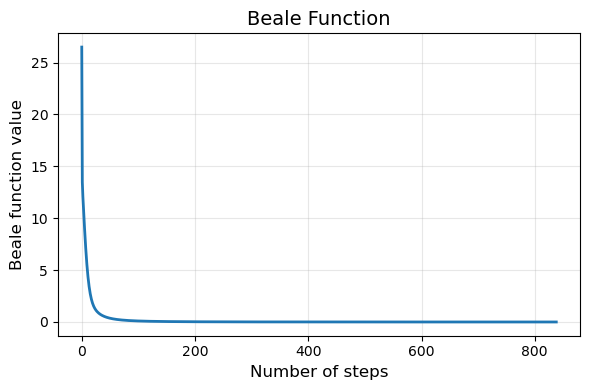

In [589]:
using PyPlot

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(opt.z_history, linewidth=2)
ax.set_title("Beale Function", fontsize=14)
ax.set_xlabel("Number of steps", fontsize=12)
ax.set_ylabel("Beale function value", fontsize=12)
ax.grid(true, alpha=0.3)
plt.tight_layout()
plt.show()

In [597]:
#This is to compute contour plots of the objective function
number_of_points = 50 #number of discretization points on each axis
margin = 4.5
x_min = 0.0 - margin #size of the domain
x_max = 0.0 + margin
y_min = 0.0 - margin
y_max = 0.0 + margin

x_points = range(x_min, x_max, length=number_of_points)
y_points = range(y_min, y_max, length=number_of_points)

# meshgrid equivalent
x_mesh = [x for x in x_points, _ in y_points]
y_mesh = [y for _ in x_points, y in y_points]

# computing the Beale function at each grid point
z = [f(x_mesh[i,j], y_mesh[i,j]) for i in 1:number_of_points, j in 1:number_of_points]

50×50 Matrix{Float64}:
      1.81854e5  142748.0        …      1.31968e5       1.69681e5
      1.67385e5       1.31398e5         1.21327e5       1.56013e5
      1.53517e5       1.20518e5         1.11133e5       1.42918e5
      1.40248e5       1.10109e5         1.01387e5  130398.0
      1.27579e5       1.00169e5     92087.5             1.18451e5
      1.15509e5   90700.1        …  83235.3             1.07079e5
      1.04039e5   81700.9           74830.5         96280.0
  93169.2         73171.9           66872.9         86055.1
  82898.7         65112.9           59362.5         76404.0
  73227.9         57524.1           52299.5         67326.8
  64156.8         50405.4        …  45683.6         58823.5
  55685.3         43756.8           39515.0         50894.1
  47813.5         37578.4           33793.7         43538.5
      ⋮                          ⋱                 
  53634.5         41951.4           42025.5         53722.2
  61954.1         48466.3           48380.0         618

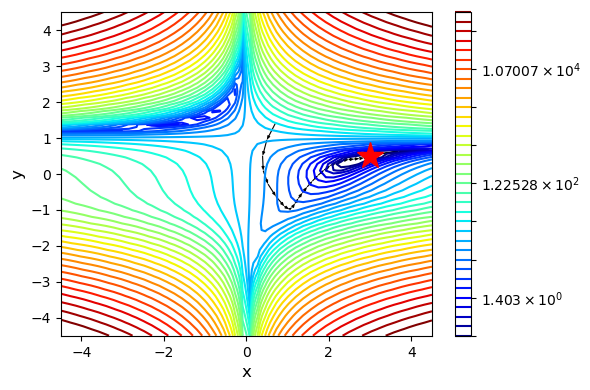

In [599]:
using PyPlot

fig, ax = plt.subplots(figsize=(6, 4))

#logarithmic contour levels
levels = 10 .^ range(-0.5, 5, length=35)

#Contour plot of the Beale function
contour_plot = ax.contour(x_mesh, y_mesh, z,
                         levels = levels,
                         norm = matplotlib.colors.LogNorm(),
                         cmap = plt.cm.jet)

# Marking the global minimum
ax.plot(minima[1], minima[2], "r*", markersize=20)

#Plot optimization path (using arrows)
if size(path, 2) > 1
    x_path = path[1, 1:end-1]
    y_path = path[2, 1:end-1]
    u = path[1, 2:end] .- path[1, 1:end-1]
    v = path[2, 2:end] .- path[2, 1:end-1]
    
    ax.quiver(x_path, y_path, u, v,
             scale_units = "xy",
             angles = "xy",
             scale = 1,
             color = "k",
             width = 0.003,
             headwidth = 3,
             headlength = 4)
end

ax.set_xlabel("x", fontsize=12)
ax.set_ylabel("y", fontsize=12)

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

plt.colorbar(contour_plot)
plt.tight_layout()
plt.show()

SGD performs frequent but noisy updates (updates only based on the local gradient information), which can help the algorithm to decrease the objective function steadily, but as explained above it often leads to:
- visible oscillations in narrow valleys
- slow convergence close to the optimum
- strong sensitivity to the choice of learning rate   

Despite its simplicity, SGD serves as the baseline method against which more advanced optimizers are compared.

### Momentum


The Momentum methois an extension ofes S that accelerates convergence and reduces oscillations in all directions (where gradients are aligned consistently). So instead of updating the parameters only based on the current gradient, it introduces a velocity term that includes past gradients. The update rules are:
$$
v_t = \gamma v_{t-1} + \eta \nabla_\theta J(\theta_t)
$$

$$
\theta_{t+1} = \theta_t - v_t$$
It usually leads to faster and more stable convergence (on non-convex problems such as the Beale function) than vanilla gradient descent.e loss surface.

In [608]:
using Random, LinearAlgebra

mutable struct MomentumOptimizer
    f::Function
    g::Function
    vars::Vector{Float64}
    lr::Float64
    momentum::Float64
    velocity::Vector{Float64}
    z_history::Vector{Float64}
    x_history::Vector{Float64}
    y_history::Vector{Float64}
    grads::Vector{Float64}
    z::Float64
    
    function MomentumOptimizer(f::Function, g::Function; 
                               x_init::Union{Nothing,Float64}=nothing, 
                               y_init::Union{Nothing,Float64}=nothing, 
                               learning_rate::Float64=0.01, 
                               momentum::Float64=0.9,
                               scale::Float64=3.0)
        
        vars = zeros(2)
        
        if x_init !== nothing
            vars[1] = x_init
        else
            vars[1] = rand() * 2scale - scale  # uniform between -scale and scale
        end
        
        if y_init !== nothing
            vars[2] = y_init
        else
            vars[2] = rand() * 2scale - scale
        end
        
        println("x_init: ", round(vars[1], digits=3))
        println("y_init: ", round(vars[2], digits=3))
        
        velocity = zeros(2)
        z_history = Float64[]
        x_history = Float64[]
        y_history = Float64[]
        grads = zeros(2)
        z = 0.0
        
        new(f, g, vars, learning_rate, momentum, velocity, 
            z_history, x_history, y_history, grads, z)
    end
end

#to make the code closer to the mathematical notation
x(opt::MomentumOptimizer) = opt.vars[1]
y(opt::MomentumOptimizer) = opt.vars[2]
dx(opt::MomentumOptimizer) = opt.grads[1]
dy(opt::MomentumOptimizer) = opt.grads[2]

function func(opt::MomentumOptimizer, variables::Vector{Float64})
    """Beale function"""
    x_val, y_val = variables
    return opt.f(x_val, y_val)
end

function gradients(opt::MomentumOptimizer, variables::Vector{Float64})
    """Gradient of the Beale function, returns:
      grads: [dx, dy] (shape is a 1-rank vector)
      dx: gradient of beale function (x-dimension of inputs)
      dy: gradient of beale function (y-dimension of inputs)"""
    x_val, y_val = variables
    return opt.g(x_val, y_val)
end


function weights_update(opt::MomentumOptimizer, grads::Vector{Float64})
    """Weights update using Momentum
      v' = gamma * v + dL/dw
      w' = w - lr * v'
    """
    opt.velocity = opt.momentum .* opt.velocity .+ grads
    opt.vars = opt.vars .- opt.lr .* opt.velocity
end

function history_update!(opt::MomentumOptimizer, z::Float64, x_val::Float64, y_val::Float64)
    """Stores the current state of the optimization"""
    push!(opt.z_history, z)
    push!(opt.x_history, x_val)
    push!(opt.y_history, y_val)
end

function train!(opt::MomentumOptimizer, max_steps::Int)
    pre_z = 0.0
    current_z = func(opt, opt.vars)
    println("steps: 0  z: ", round(current_z, digits=6), 
            "  x: ", round(x(opt), digits=5), 
            "  y: ", round(y(opt), digits=5))
    
    # Open file for writing
    open("momentum.txt", "w") do file
        write(file, string(round(x(opt), digits=5), "  ", round(y(opt), digits=5), "\n"))
        
        for step in 1:max_steps
            opt.z = func(opt, opt.vars)
            history_update!(opt, opt.z, x(opt), y(opt))
            
            opt.grads = gradients(opt, opt.vars)
            weights_update(opt, opt.grads)
            
            write(file, string(round(x(opt), digits=5), "  ", round(y(opt), digits=5), "\n"))
            
            if step % 100 == 0
                current_z = func(opt, opt.vars)
                println("steps: ", step, "  z: ", round(current_z, digits=6), 
                        "  x: ", round(x(opt), digits=5), 
                        "  y: ", round(y(opt), digits=5), 
                        "  dx: ", round(dx(opt), digits=5), 
                        "  dy: ", round(dy(opt), digits=5))
            end
            
            if abs(pre_z - opt.z) < 1e-7
                println("Enough convergence")
                current_z = func(opt, opt.vars)
                println("steps: ", step, "  z: ", round(current_z, digits=6), 
                        "  x: ", round(x(opt), digits=5), 
                        "  y: ", round(y(opt), digits=5))
                history_update!(opt, current_z, x(opt), y(opt))
                break
            end
            
            pre_z = opt.z
        end
    end
    
    opt.x_history = Float64.(opt.x_history)
    opt.y_history = Float64.(opt.y_history)
    
    opt_path = hcat(opt.x_history, opt.y_history)'
    
    return opt_path
end

function get_path(opt::MomentumOptimizer)
    """returns the optimization path as a 2 x N matrix"""
    return hcat(opt.x_history, opt.y_history)'
end

get_path (generic function with 1 method)

In [610]:
opt = MomentumOptimizer(f, gradients, x_init=0.7, y_init=1.4, learning_rate=0.01, momentum=0.9)
@time train!(opt, 1000)

x_init: 0.7
y_init: 1.4
steps: 0  z: 26.496662  x: 0.7  y: 1.4
steps: 100  z: 0.09951  x: 4.4641  y: 0.71417  dx: 0.0968  dy: -0.29558
steps: 200  z: 0.039972  x: 3.7021  y: 0.63209  dx: 0.07884  dy: 0.01149
steps: 300  z: 0.001087  x: 3.08637  y: 0.52077  dx: 0.02342  dy: 0.00558
Enough convergence
steps: 379  z: 1.0e-6  x: 3.00194  y: 0.50048
  0.645394 seconds (109.37 k allocations: 7.192 MiB, 99.12% compilation time)


2×380 adjoint(::Matrix{Float64}) with eltype Float64:
 0.7  0.495516  0.326008   0.265007   …  3.0022    3.00207   3.00194
 1.4  0.943951  0.410376  -0.0966062     0.500549  0.500516  0.500485

In [541]:
println("Global minima")
println("x*: $(round(minima[1], digits=2))  y*: $(round(minima[2], digits=2))")

println("Solution using the gradient descent")
println("x: $(round(x(opt), digits=4))  y: $(round(y(opt), digits=4))")

Global minima
x*: 3.0  y*: 0.5
Solution using the gradient descent
x: 3.0019  y: 0.5005


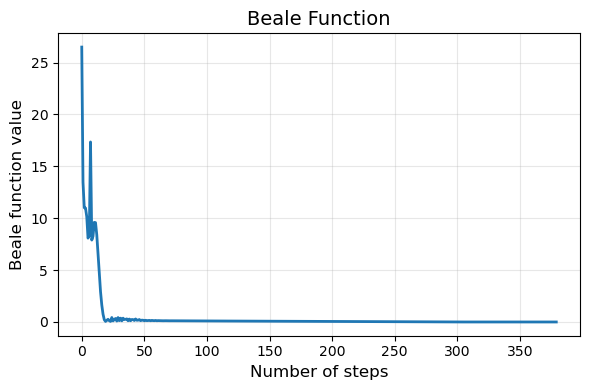

In [542]:
using PyPlot

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(opt.z_history, linewidth=2)
ax.set_title("Beale Function", fontsize=14)
ax.set_xlabel("Number of steps", fontsize=12)
ax.set_ylabel("Beale function value", fontsize=12)
ax.grid(true, alpha=0.3)
plt.tight_layout()
plt.show()

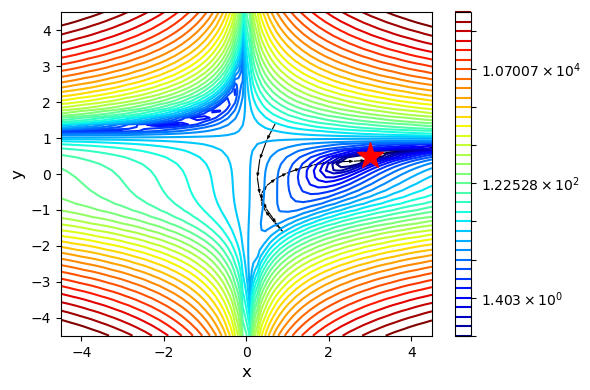

In [614]:
using PyPlot

fig, ax = plt.subplots(figsize=(6, 4))
path = get_path(opt) 

#logarithmic contour levels
levels = 10 .^ range(-0.5, 5, length=35)

#Contour plot of the Beale function
contour_plot = ax.contour(x_mesh, y_mesh, z,
                         levels = levels,
                         norm = matplotlib.colors.LogNorm(),
                         cmap = plt.cm.jet)

#Min point
ax.plot(minima[1], minima[2], "r*", markersize=20)

#Plot with arrows
if size(path, 2) > 1
    x_path = path[1, 1:end-1]
    y_path = path[2, 1:end-1]
    u = path[1, 2:end] .- path[1, 1:end-1]
    v = path[2, 2:end] .- path[2, 1:end-1]
    
    ax.quiver(x_path, y_path, u, v, scale_units = "xy", angles = "xy",scale = 1, color = "k", width = 0.003, headwidth = 3, headlength = 4)
end

ax.set_xlabel("x", fontsize=12)
ax.set_ylabel("y", fontsize=12)

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

plt.colorbar(contour_plot)
plt.tight_layout()
plt.show()

The trajectory obtained with the momentum is smoother than the one obtained with vanilla gradient descent. The momentum coefficient 
$\gamma$ : 0.9 helps:
- damp oscillations in directions where gradients accumulate fast
- speed up convergence along directions where gradients remain consistent over several iterations   

Compared to SGD, convergence toward the mimimum is faster and more stable.

### Nesterov Accelerated Gradient


Nesterov momentum is an improvement of the classical momentum method, because it comptues the gradient after a "look-ahead" step in the direction of accumulated velocity. The update rules can be written as:

$$
v_t = \gamma v_{t-1} + \eta \nabla_\theta J(\theta_t - \gamma v_{t-1})
$$
$$
\theta_{t+1} = \theta_t - v_t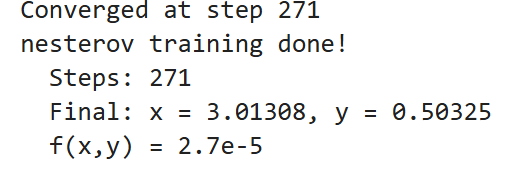
$$

This allows the optimizer to make more informed updates, instead of reacting only to past gradients. Therefore, Nesterov Accelerated Gradient tends to correct its trajectory earlier than classical momentum, avoid overshooting near the minimum, and react faster to changes in curvature of the loss surface.

In [622]:
using Random

mutable struct NesterovMomentumOptimizer
    f::Function
    g::Function
    vars::Vector{Float64}
    lr::Float64
    momentum::Float64
    velocity::Vector{Float64}
    z_history::Vector{Float64}
    x_history::Vector{Float64}
    y_history::Vector{Float64}
    grads::Vector{Float64}
    z::Float64
    path::Matrix{Float64}
    
    function NesterovMomentumOptimizer(function_, gradients_;
                                       x_init=nothing, y_init=nothing, 
                                       learning_rate=0.01, momentum=0.9)
        scale = 3.0
        vars = zeros(2)
        
        if x_init !== nothing
            vars[1] = x_init
        else
            vars[1] = rand(Uniform(-scale, scale))
            println("x_init: ", round(vars[1], digits=3))
        end
        
        if y_init !== nothing
            vars[2] = y_init
        else
            vars[2] = rand(Uniform(-scale, scale))
            println("y_init: ", round(vars[2], digits=3))
        end
        
        println("x_init: ", round(vars[1], digits=3))
        println("y_init: ", round(vars[2], digits=3))
        
        new(function_, gradients_, vars, learning_rate, momentum,
            zeros(2), Float64[], Float64[], Float64[], zeros(2), 0.0, zeros(2, 0))
    end
end

x(opt::NesterovMomentumOptimizer) = opt.vars[1]
y(opt::NesterovMomentumOptimizer) = opt.vars[2]
dx(opt::NesterovMomentumOptimizer) = opt.grads[1]
dy(opt::NesterovMomentumOptimizer) = opt.grads[2]
v_x(opt::NesterovMomentumOptimizer) = opt.velocity[1]
v_y(opt::NesterovMomentumOptimizer) = opt.velocity[2]

function func(opt::NesterovMomentumOptimizer, variables::Vector{Float64})
    """Beale function """
    x_val, y_val = variables
    return opt.f(x_val, y_val)
end

function gradients(opt::MomentumOptimizer, variables::Vector{Float64})
    """Gradient of Beale function"""
    x_val, y_val = variables
    return opt.g(x_val, y_val)
end


function weights_update!(opt::NesterovMomentumOptimizer, grads::Vector{Float64})
    """Weights update using Nesterov Momentum
        v' = gamma*v - lr*grads
        w' = w + v """
    opt.velocity = opt.momentum * opt.velocity - opt.lr * grads
    opt.vars = opt.vars + opt.velocity
end

function history_update!(opt::NesterovMomentumOptimizer, z::Float64, x_val::Float64, y_val::Float64)
    """Stores the current iterations"""
    push!(opt.z_history, z)
    push!(opt.x_history, x_val)
    push!(opt.y_history, y_val)
end

function train!(opt::NesterovMomentumOptimizer, max_steps::Int)
     """This runs gradient descent for a specified number of iteration (max_steps)"""
    pre_z = 0.0
    
    println("steps: 0  z: ", round(func(opt, opt.vars), digits=6),
            "  x: ", round(x(opt), digits=5),
            "  y: ", round(y(opt), digits=5))
    
    file = open("nesterov_momentum.txt", "w")
    write(file, "$(x(opt))  $(y(opt))\n")
    
    for step in 1:max_steps
        opt.z = func(opt, opt.vars)
        history_update!(opt, opt.z, x(opt), y(opt))
        
        # Nesterov momentum: 
        x_ahead = x(opt) + opt.momentum * v_x(opt)
        y_ahead = y(opt) + opt.momentum * v_y(opt)
        
        opt.grads = gradients(opt, [x_ahead, y_ahead])
        weights_update!(opt, opt.grads)
        
        write(file, "$(x(opt))  $(y(opt))\n")
        
        if step % 100 == 0
            println("steps: $step  z: ", round(func(opt, opt.vars), digits=6),
                    "  x: ", round(x(opt), digits=5),
                    "  y: ", round(y(opt), digits=5),
                    "  dx: ", round(dx(opt), digits=5),
                    "  dy: ", round(dy(opt), digits=5))
        end
        
        if abs(pre_z - opt.z) < 1e-7
            println("Enough convergence")
            println("steps: $step  z: ", round(func(opt, opt.vars), digits=6),
                    "  x: ", round(x(opt), digits=5),
                    "  y: ", round(y(opt), digits=5))
            opt.z = func(opt, opt.vars)
            history_update!(opt, opt.z, x(opt), y(opt))
            break
        end
        
        pre_z = opt.z
    end
    
    close(file)
    opt.path = hcat(opt.x_history, opt.y_history)'
end

train! (generic function with 9 methods)

In [624]:
#runs it with the same specific initialization values
opt = NesterovMomentumOptimizer(f, gradients; x_init=0.7, y_init=1.4, learning_rate=0.01, momentum=0.9)

x_init: 0.7
y_init: 1.4


NesterovMomentumOptimizer(f, gradients, [0.7, 1.4], 0.01, 0.9, [0.0, 0.0], Float64[], Float64[], Float64[], [0.0, 0.0], 0.0, Matrix{Float64}(undef, 2, 0))

In [628]:
#Training for max 1000 iterations (just like for the other optimizers)
@time train!(opt, 1000)

steps: 0  z: 1.0e-6  x: 3.00219  y: 0.50054
Enough convergence
steps: 2  z: 1.0e-6  x: 3.00196  y: 0.50049
  0.002334 seconds (223 allocations: 19.188 KiB)


2×240 adjoint(::Matrix{Float64}) with eltype Float64:
 0.7  0.495516  0.39317   0.408305  …  3.00219   3.00207   3.00196
 1.4  0.943951  0.499035  0.088487     0.500545  0.500516  0.500488

In [632]:
println("Global minima")
println("x*: ", round(minima[1], digits=2), " y*:", round(minima[2], digits=2))

println("Solution using the gradient descent")
println("x:", round(x(opt), digits=4), " y:", round(y(opt), digits=4))

Global minima
x*: 3.0 y*:0.5
Solution using the gradient descent
x:3.002 y:0.5005


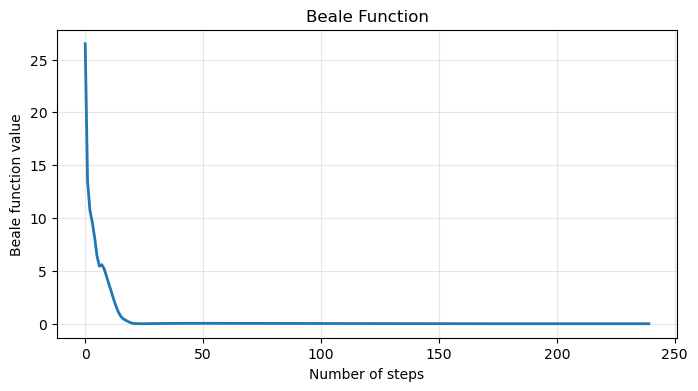

In [634]:
using PyPlot

plt.figure(figsize=(8, 4))
plt.plot(opt.z_history, linewidth=2)
plt.title("Beale Function")
plt.xlabel("Number of steps")
plt.ylabel("Beale function value")
plt.grid(true, alpha=0.3)
plt.show()

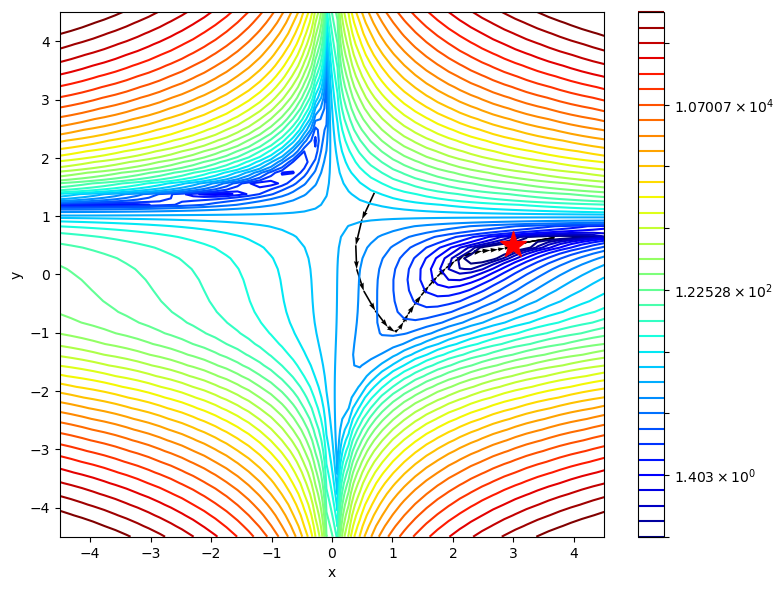

In [642]:
using PyPlot
using PyCall

#log
@pyimport matplotlib.colors as mcolors
path = opt.path
# Create figure
fig, ax = plt.subplots(figsize=(8, 6))

#contour plot
contour = ax.contour(x_mesh, y_mesh, z, 
                     levels=10 .^ range(-0.5, 5, length=35),  # logspace equivalent
                     norm=mcolors.LogNorm(), 
                     cmap=plt.cm.jet)

# minima point
ax.plot([minima[1]], [minima[2]], 
        "r*", markersize=20)

#plot for the path (with 2D arrows)
if size(path, 2) > 1
    x_start = path[1, 1:end-1]
    y_start = path[2, 1:end-1]
    
    u = path[1, 2:end] .- path[1, 1:end-1]  # dx
    v = path[2, 2:end] .- path[2, 1:end-1]  # dy
    
    ax.quiver(x_start, y_start, u, v,
              scale_units="xy", 
              angles="xy", 
              scale=1, 
              color="k",
              width=0.003,
              headwidth=3,
              headlength=5)
end

ax.set_xlabel("x")
ax.set_ylabel("y")

ax.set_xlim((x_min, x_max))
ax.set_ylim((y_min, y_max))

plt.colorbar(contour)

plt.tight_layout()
plt.show()

The trajectory obtained with NAG is smoother and more aligned with the valley of the Beale function than standard momentum, especially in curved regions where the path shows less "abrupt" direction changes, and converges in a more effective way towards thr minimum.

### Adagrad


Adagrad adapts the learning rate individually for each parameter based on the historical magnitude of gradients:

$$
\theta_{t+1,i} =
\theta_{t,i}
-
\frac{\eta}{\sqrt{G_{t,ii}} + \varepsilon} g_{t,i}
$$

where \( G_{t,ii} \) is the sum of squared past gradients for parameter \( i \).

This results in larger updates for infrequent parameters, and smaller updates for frequently updated ones.

While Adagrad performs well on sparse problems, its main drawback is that the learning rate continually decreases and may become too small to allow more learning.

In [648]:
using Random

mutable struct AdagradOptimizer
    f::Function
    g::Function
    vars::Vector{Float64}
    lr::Float64
    grads_squared::Vector{Float64}
    epsilon::Float64
    z_history::Vector{Float64}
    x_history::Vector{Float64}
    y_history::Vector{Float64}
    grads::Vector{Float64}
    z::Float64
    path::Matrix{Float64}
    
    function AdagradOptimizer(function_, gradients_;
                              x_init=nothing, y_init=nothing, 
                              learning_rate=0.01, initial_accumulator_value=0.1)
        scale = 3.0
        vars = zeros(2)
        
        if x_init !== nothing
            vars[1] = x_init
        else
            vars[1] = rand() * 2scale - scale  # Uniform in [-scale, scale]
        end
        
        if y_init !== nothing
            vars[2] = y_init
        else
            vars[2] = rand() * 2scale - scale
        end
        
        println("x_init: ", round(vars[1], digits=3))
        println("y_init: ", round(vars[2], digits=3))
        
        #initializing the gradient accumulator
        grads_squared = fill(initial_accumulator_value, 2)
        
        new(function_, gradients_, vars, learning_rate, grads_squared,
            1e-7, Float64[], Float64[], Float64[], zeros(2), 0.0, zeros(2, 0))
    end
end

x(opt::AdagradOptimizer) = opt.vars[1]
y(opt::AdagradOptimizer) = opt.vars[2]
dx(opt::AdagradOptimizer) = opt.grads[1]
dy(opt::AdagradOptimizer) = opt.grads[2]

function func(opt::AdagradOptimizer, variables::Vector{Float64})
    """Beale function (same as before) """
    x_val, y_val = variables
    return opt.f(x_val, y_val)
end

function gradients(opt::AdagradOptimizer, variables::Vector{Float64})
    """gradient of Beale function (same as before)"""
    x_val, y_val = variables
    return opt.g(x_val, y_val)
end

function weights_update!(opt::AdagradOptimizer, grads::Vector{Float64})
    """Weights update using adagrad
        grads2 = grads2+grads**2
        w' = w -lr*grads/(sqrt(grads2) + epsilon)"""
    opt.grads_squared = opt.grads_squared + grads.^2
    opt.vars = opt.vars - opt.lr * grads ./ (sqrt.(opt.grads_squared) .+ opt.epsilon)
end

function history_update!(opt::AdagradOptimizer, z::Float64, x_val::Float64, y_val::Float64)
    push!(opt.z_history, z)
    push!(opt.x_history, x_val)
    push!(opt.y_history, y_val)
end

function train!(opt::AdagradOptimizer, max_steps::Int)
    """runs the optimizer for max_steps iterations (same structure as above)"""
    pre_z = 0.0
    
    println("steps: 0  z: ", round(func(opt, opt.vars), digits=6),
            "  x: ", round(x(opt), digits=5),
            "  y: ", round(y(opt), digits=5))

    file = open("adagrad.txt", "w")
    write(file, "$(x(opt))  $(y(opt))\n")
    
    for step in 1:max_steps
        opt.z = func(opt, opt.vars)
        history_update!(opt, opt.z, x(opt), y(opt))
        
        opt.grads = gradients(opt, opt.vars)
        weights_update!(opt, opt.grads)
        
        write(file, "$(x(opt))  $(y(opt))\n")
        
        if step % 100 == 0
            println("steps: $step  z: ", round(func(opt, opt.vars), digits=6),
                    "  x: ", round(x(opt), digits=5),
                    "  y: ", round(y(opt), digits=5),
                    "  dx: ", round(dx(opt), digits=5),
                    "  dy: ", round(dy(opt), digits=5))
        end
        
        if abs(pre_z - opt.z) < 1e-7
            println("Enough convergence")
            println("steps: $step  z: ", round(func(opt, opt.vars), digits=6),
                    "  x: ", round(x(opt), digits=5),
                    "  y: ", round(y(opt), digits=5))
            opt.z = func(opt, opt.vars)
            history_update!(opt, opt.z, x(opt), y(opt))
            break
        end
        
        pre_z = opt.z
    end
    
    close(file)

    opt.path = hcat(opt.x_history, opt.y_history)'
end

train! (generic function with 9 methods)

In [650]:
# We can now run it with the same specific initialization
opt = AdagradOptimizer(f, gradients; x_init=0.7, y_init=1.4, learning_rate=0.2)


x_init: 0.7
y_init: 1.4


AdagradOptimizer(f, gradients, [0.7, 1.4], 0.2, [0.1, 0.1], 1.0e-7, Float64[], Float64[], Float64[], [0.0, 0.0], 0.0, Matrix{Float64}(undef, 2, 0))

In [654]:
#training (max 1000 iterations)
@time train!(opt, 1000)

steps: 0  z: 0.002194  x: 2.89008  y: 0.47105
steps: 100  z: 0.001563  x: 2.90635  y: 0.47552  dx: -0.0314  dy: -0.0141
steps: 200  z: 0.001125  x: 2.91993  y: 0.4792  dx: -0.0263  dy: -0.01166
steps: 300  z: 0.000816  x: 2.93134  y: 0.48225  dx: -0.02216  dy: -0.00973
steps: 400  z: 0.000597  x: 2.94097  y: 0.48481  dx: -0.01877  dy: -0.00817
steps: 500  z: 0.000439  x: 2.94916  y: 0.48696  dx: -0.01597  dy: -0.0069
steps: 600  z: 0.000324  x: 2.95613  y: 0.48879  dx: -0.01363  dy: -0.00585
steps: 700  z: 0.00024  x: 2.96209  y: 0.49034  dx: -0.01168  dy: -0.00498
steps: 800  z: 0.000179  x: 2.9672  y: 0.49166  dx: -0.01002  dy: -0.00426
steps: 900  z: 0.000133  x: 2.9716  y: 0.49279  dx: -0.00862  dy: -0.00365
steps: 1000  z: 0.0001  x: 2.97538  y: 0.49376  dx: -0.00743  dy: -0.00314
  0.049296 seconds (23.37 k allocations: 1.822 MiB, 69.14% gc time)


2×2000 adjoint(::Matrix{Float64}) with eltype Float64:
 0.7  0.500024  0.433888  0.399557  0.383224  …  2.97527   2.97531   2.97534
 1.4  1.2       1.1182    1.0606    1.01436      0.493735  0.493744  0.493753

In [656]:
println("Global minima")
println("x*: ", round(minima[1], digits=2), "  y*:", round(minima[2], digits=2))

println("Solution using the gradient descent")
println("x: ", round(opt.vars[1], digits=4), "  y:", round(opt.vars[2], digits=4))

Global minima
x*: 3.0  y*:0.5
Solution using the gradient descent
x: 2.9754  y:0.4938


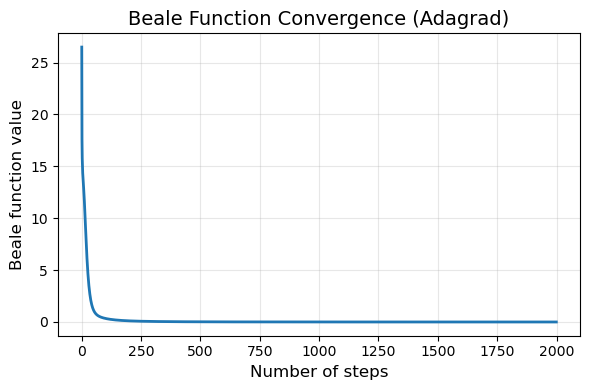

In [658]:
using PyPlot

plt.figure(figsize=(6, 4))
plt.plot(opt.z_history, linewidth=2)
plt.title("Beale Function Convergence (Adagrad)", fontsize=14)
plt.xlabel("Number of steps", fontsize=12)
plt.ylabel("Beale function value", fontsize=12)
plt.grid(true, alpha=0.3)
plt.tight_layout()
plt.show()

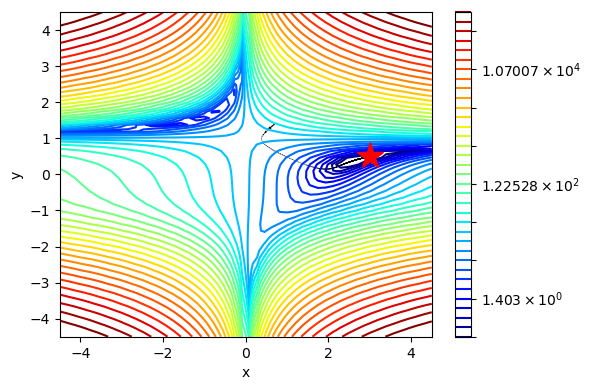

In [662]:
using PyPlot
using PyCall

#importing lognorm
@pyimport matplotlib.colors as mcolors

path = opt.path

fig, ax = plt.subplots(figsize=(6, 4))

# a contour plot with log-spaced levels
levels = 10 .^ range(-0.5, 5, length=35)
contour = ax.contour(x_mesh, y_mesh, z, 
                     levels=levels,
                     norm=mcolors.LogNorm(), 
                     cmap=plt.cm.jet)

#minima point
ax.plot(minima[1], minima[2], 
        "r*", markersize=20)

#plot for the optimization path (with arrows)
if size(path, 2) > 1
    # Start points (x, y)
    x_start = path[1, 1:end-1]
    y_start = path[2, 1:end-1]
    
    # Direction vectors (dx, dy)
    u = path[1, 2:end] .- path[1, 1:end-1]
    v = path[2, 2:end] .- path[2, 1:end-1]
    
    ax.quiver(x_start, y_start, u, v, scale_units="xy", angles="xy", scale=1, color="k", width=0.003, headwidth=3)
end

ax.set_xlabel("x")
ax.set_ylabel("y")

ax.set_xlim((x_min, x_max))
ax.set_ylim((y_min, y_max))

plt.colorbar(contour)

plt.tight_layout()
plt.show()

### Adam


Adam combines the benefits of Momentum and RMSprop by maintaining: an exponential average of gradients (first moment), an exponential average of squared gradients (second moment). 

$$
m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t
$$
$$
v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2
$$

Bias-corrected estimates are used:
$$
\hat{m}_t = \frac{m_t}{1 - \beta_1^t},
\quad
\hat{v}_t = \frac{v_t}{1 - \beta_2^t}
$$

$$
\theta_{t+1} =
\theta_t -
\frac{\eta}{\sqrt{\hat{v}_t} + \varepsilon} \hat{m}_t
$$

Adam is widely used due to its fast convergence, its robustness to noisy gradients, and minimal tuning requirements.

In [669]:
using Random

mutable struct AdamOptimizer
    f::Function
    g::Function
    vars::Vector{Float64}
    lr::Float64
    grads_first_moment::Vector{Float64}
    grads_second_moment::Vector{Float64}
    beta1::Float64
    beta2::Float64
    epsilon::Float64
    grads_first_moment_unbiased::Vector{Float64}
    grads_second_moment_unbiased::Vector{Float64}
    z_history::Vector{Float64}
    x_history::Vector{Float64}
    y_history::Vector{Float64}
    grads::Vector{Float64}
    z::Float64
    path::Matrix{Float64}
    
    function AdamOptimizer(function_, gradients_;
                           x_init=nothing, y_init=nothing,
                           learning_rate=0.001, beta1=0.9, beta2=0.999, epsilon=1e-8)
        scale = 3.0
        vars = zeros(2)
        
        if x_init !== nothing
            vars[1] = x_init
        else
            vars[1] = rand() * 2scale - scale  # Uniform in [-scale, scale]
        end
        
        if y_init !== nothing
            vars[2] = y_init
        else
            vars[2] = rand() * 2scale - scale
        end
        
        println("x_init: ", round(vars[1], digits=3))
        println("y_init: ", round(vars[2], digits=3))
        
        new(function_, gradients_, vars, learning_rate,
            zeros(2), zeros(2), beta1, beta2, epsilon,
            zeros(2), zeros(2),
            Float64[], Float64[], Float64[], zeros(2), 0.0, zeros(2, 0))
    end
end

x(opt::AdamOptimizer) = opt.vars[1]
y(opt::AdamOptimizer) = opt.vars[2]
dx(opt::AdamOptimizer) = opt.grads[1]
dy(opt::AdamOptimizer) = opt.grads[2]

function func(opt::AdamOptimizer, variables::Vector{Float64})
    """Beale function"""
    x_val, y_val = variables
    return opt.f(x_val, y_val)
end

function gradients(opt::AdamOptimizer, variables::Vector{Float64})
    """Gradient of Beale function"""
    x_val, y_val = variables
    return opt.g(x_val, y_val)
end

function weights_update!(opt::AdamOptimizer, grads::Vector{Float64}, time::Int)
    """Weights update using Adam, with
        g1 =beta1 * g1 + (1 - beta1) * grads
        g2 =beta2 * g2 + (1 - beta2) * g2
        g1_unbiased = g1 / (1 - beta1**time)
        g2_unbiased = g2 / (1 - beta2**time)
        w = w - lr * g1_unbiased / (sqrt(g2_unbiased) + epsilon)"""
    opt.grads_first_moment = opt.beta1 * opt.grads_first_moment .+ 
                            (1.0 - opt.beta1) .* grads
    opt.grads_second_moment = opt.beta2 * opt.grads_second_moment .+ 
                             (1.0 - opt.beta2) .* grads.^2
    
    opt.grads_first_moment_unbiased = opt.grads_first_moment ./ (1.0 - opt.beta1^time)
    opt.grads_second_moment_unbiased = opt.grads_second_moment ./ (1.0 - opt.beta2^time)
    
    opt.vars = opt.vars .- opt.lr .* opt.grads_first_moment_unbiased ./
               (sqrt.(opt.grads_second_moment_unbiased) .+ opt.epsilon)
end

function history_update!(opt::AdamOptimizer, z::Float64, x_val::Float64, y_val::Float64)
    push!(opt.z_history, z)
    push!(opt.x_history, x_val)
    push!(opt.y_history, y_val)
end

function train!(opt::AdamOptimizer, max_steps::Int)
    opt.z_history = Float64[]
    opt.x_history = Float64[]
    opt.y_history = Float64[]
    
    pre_z = 0.0
    println("steps: 0  z: ", round(func(opt, opt.vars), digits=6),
            "  x: ", round(x(opt), digits=5),
            "  y: ", round(y(opt), digits=5))
    
    file = open("adam.txt", "w")
    write(file, "$(x(opt))  $(y(opt))\n")
    
    for step in 1:max_steps
        opt.z = func(opt, opt.vars)
        history_update!(opt, opt.z, x(opt), y(opt))
        
        opt.grads = gradients(opt, opt.vars)
        weights_update!(opt, opt.grads, step)
        
        write(file, "$(x(opt))  $(y(opt))\n")
        
        if step % 100 == 0
            println("steps: $step  z: ", round(func(opt, opt.vars), digits=6),
                    "  x: ", round(x(opt), digits=5),
                    "  y: ", round(y(opt), digits=5),
                    "  dx: ", round(dx(opt), digits=5),
                    "  dy: ", round(dy(opt), digits=5))
        end
        
        if abs(pre_z - opt.z) < 1e-7
            println("Enough convergence")
            println("steps: $step  z: ", round(func(opt, opt.vars), digits=6),
                    "  x: ", round(x(opt), digits=5),
                    "  y: ", round(y(opt), digits=5))
            opt.z = func(opt, opt.vars)
            history_update!(opt, opt.z, x(opt), y(opt))
            break
        end
        
        pre_z = opt.z
    end
    
    close(file)
    opt.path = hcat(opt.x_history, opt.y_history)'
end

train! (generic function with 9 methods)

In [671]:
# Using mainly the same specific initialization values as for the other optimizers
opt = AdamOptimizer(f, gradients; 
                    x_init=0.7, y_init=1.4, 
                    learning_rate=0.1, beta1=0.9, beta2=0.999, epsilon=1e-8)

x_init: 0.7
y_init: 1.4


AdamOptimizer(f, gradients, [0.7, 1.4], 0.1, [0.0, 0.0], [0.0, 0.0], 0.9, 0.999, 1.0e-8, [0.0, 0.0], [0.0, 0.0], Float64[], Float64[], Float64[], [0.0, 0.0], 0.0, Matrix{Float64}(undef, 2, 0))

In [673]:
# max 1000 iterations
@time train!(opt, 1000)

steps: 0  z: 26.496662  x: 0.7  y: 1.4
steps: 100  z: 0.024316  x: 2.6804  y: 0.41601  dx: -0.26027  dy: 0.25021
steps: 200  z: 0.001374  x: 2.9119  y: 0.47705  dx: -0.02968  dy: -0.01318
steps: 300  z: 8.6e-5  x: 2.97707  y: 0.4942  dx: -0.0071  dy: -0.00253
steps: 400  z: 4.0e-6  x: 2.99522  y: 0.4988  dx: -0.00144  dy: -0.00051
Enough convergence
steps: 409  z: 3.0e-6  x: 2.9959  y: 0.49897
  0.671520 seconds (96.30 k allocations: 5.896 MiB, 99.00% compilation time)


2×410 adjoint(::Matrix{Float64}) with eltype Float64:
 0.7  0.6  0.503824  0.414125  0.333381  …  2.99576   2.99583   2.9959
 1.4  1.3  1.20287   1.11006   1.02256      0.498937  0.498955  0.498973

In [675]:
println("Global minima")
println("x*: ", round(minima[1], digits=2), "  y*: ", round(minima[2], digits=2))

println("\nSolution using Adam optimization")
println("x: ", round(x(opt), digits=4), "  y: ", round(y(opt), digits=4))

Global minima
x*: 3.0  y*: 0.5

Solution using Adam optimization
x: 2.9959  y: 0.499


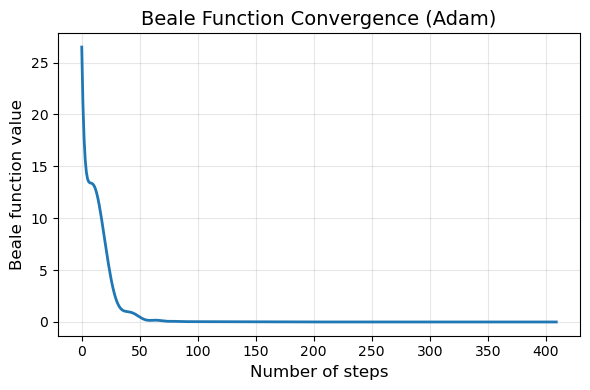

In [677]:
using PyPlot

plt.figure(figsize=(6, 4))
plt.plot(opt.z_history, linewidth=2)
plt.title("Beale Function Convergence (Adam)", fontsize=14)
plt.xlabel("Number of steps", fontsize=12)
plt.ylabel("Beale function value", fontsize=12)
plt.grid(true, alpha=0.3)
plt.tight_layout()
plt.show()

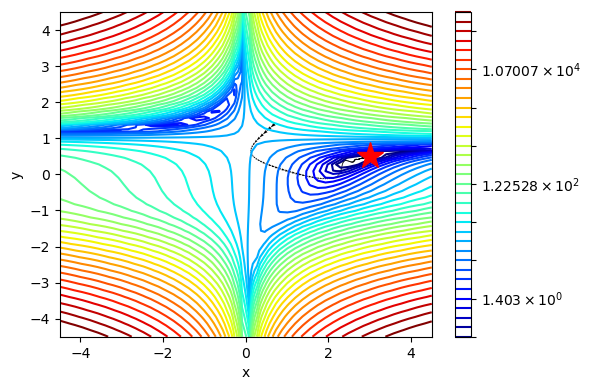

In [679]:
using PyPlot
using PyCall

#lognorm
@pyimport matplotlib.colors as mcolors
path = opt.path

fig, ax = plt.subplots(figsize=(6, 4))

#contour levels and plot
levels = 10 .^ range(-0.5, 5, length=35)
contour = ax.contour(x_mesh, y_mesh, z, 
                     levels=levels,
                     norm=mcolors.LogNorm(), 
                     cmap=plt.cm.jet)

#min
ax.plot(minima[1], minima[2], 
        "r*", markersize=20)

#plot the path
if size(path, 2) > 1
    x_start = path[1, 1:end-1]
    y_start = path[2, 1:end-1]
    
    u = path[1, 2:end] .- path[1, 1:end-1]
    v = path[2, 2:end] .- path[2, 1:end-1]
    
    ax.quiver(x_start, y_start, u, v,
              scale_units="xy", 
              angles="xy", 
              scale=1, 
              color="k",
              width=0.003,
              headwidth=3)
end

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_xlim((x_min, x_max))
ax.set_ylim((y_min, y_max))

plt.colorbar(contour)
plt.tight_layout()
plt.show()

### RMSPROP


RMSprop deals with the diminishing learning rate of Adagrad by replacing the cumulative sum with an exponentially decaying average:

$$
E[g^2]_t = \gamma E[g^2]_{t-1} + (1 - \gamma) g_t^2
$$
$$
\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{E[g^2]_t} + \varepsilon} g_t
$$

This allows RMSprop to maintain adaptive learning rates, prevent premature stagnation, and perform well on non-stationary objectives.
It is particularly effective for training neural networks.

In [738]:
using Random

mutable struct RMSPropOptimizer
    f::Function
    g::Function
    vars::Vector{Float64}
    lr::Float64
    grads_squared::Vector{Float64}
    decay::Float64
    epsilon::Float64
    z_history::Vector{Float64}
    x_history::Vector{Float64}
    y_history::Vector{Float64}
    grads::Vector{Float64}
    z::Float64
    path::Matrix{Float64}
    
    function RMSPropOptimizer(function_, gradients_;
                              x_init=nothing, y_init=nothing,
                              learning_rate=0.001, decay=0.9, epsilon=1e-10)
        scale = 3.0
        vars = zeros(2)
        
        if x_init !== nothing
            vars[1] = x_init
        else
            vars[1] = rand() * 2scale - scale  # Uniform in [-scale, scale]
        end
        
        if y_init !== nothing
            vars[2] = y_init
        else
            vars[2] = rand() * 2scale - scale
        end
        
        println("x_init: ", round(vars[1], digits=3))
        println("y_init: ", round(vars[2], digits=3))
        
        new(function_, gradients_, vars, learning_rate,
            zeros(2), decay, epsilon,
            Float64[], Float64[], Float64[], zeros(2), 0.0, zeros(2, 0))
    end
end

x(opt::RMSPropOptimizer) = opt.vars[1]
y(opt::RMSPropOptimizer) = opt.vars[2]
dx(opt::RMSPropOptimizer) = opt.grads[1]
dy(opt::RMSPropOptimizer) = opt.grads[2]

function func(opt::RMSPropOptimizer, variables::Vector{Float64})
    """Beale function"""
    x_val, y_val = variables
    return opt.f(x_val, y_val)
end

function gradients(opt::RMSPropOptimizer, variables::Vector{Float64})
    """Gradient of Beale function"""
    x_val, y_val = variables
    return opt.g(x_val, y_val)
end

function weights_update!(opt::RMSPropOptimizer, grads::Vector{Float64})
    """Weights update using RMSprop
        grads2 = decay * grads2 + (1 - decay) * grad2**2
        w' = w - lr * grads / (sqrt(grad2) + epsilon)"""
    opt.grads_squared = opt.decay * opt.grads_squared .+ 
                       (1.0 - opt.decay) .* grads.^2
    opt.vars = opt.vars .- opt.lr .* grads ./ 
               (sqrt.(opt.grads_squared) .+ opt.epsilon)
end

function history_update!(opt::RMSPropOptimizer, z::Float64, x_val::Float64, y_val::Float64)
    push!(opt.z_history, z)
    push!(opt.x_history, x_val)
    push!(opt.y_history, y_val)
end

function train!(opt::RMSPropOptimizer, max_steps::Int)
    """optimizer for max_steps iterations"""
    pre_z = 0.0
    println("steps: 0  z: ", round(func(opt, opt.vars), digits=6),
            "  x: ", round(x(opt), digits=5),
            "  y: ", round(y(opt), digits=5))
    
    # Open file for writing
    file = open("rmsprop.txt", "w")
    write(file, "$(x(opt))  $(y(opt))\n")
    
    for step in 1:max_steps
        opt.z = func(opt, opt.vars)
        history_update!(opt, opt.z, x(opt), y(opt))
        
        opt.grads = gradients(opt, opt.vars)
        weights_update!(opt, opt.grads)
        
        write(file, "$(x(opt))  $(y(opt))\n")
        
        if step % 100 == 0
            println("steps: $step  z: ", round(func(opt, opt.vars), digits=6),
                    "  x: ", round(x(opt), digits=5),
                    "  y: ", round(y(opt), digits=5),
                    "  dx: ", round(dx(opt), digits=5),
                    "  dy: ", round(dy(opt), digits=5))
        end
        
        if abs(pre_z - opt.z) < 1e-7
            println("Enough convergence")
            println("steps: $step  z: ", round(func(opt, opt.vars), digits=6),
                    "  x: ", round(x(opt), digits=5),
                    "  y: ", round(y(opt), digits=5))
            opt.z = func(opt, opt.vars)
            history_update!(opt, opt.z, x(opt), y(opt))
            break
        end
        
        pre_z = opt.z
    end
    
    close(file)
    
    opt.path = hcat(opt.x_history, opt.y_history)'
end

train! (generic function with 9 methods)

In [740]:
#same initialization values
opt = RMSPropOptimizer(f, gradients; 
                       x_init=0.7, y_init=1.4, 
                       learning_rate=0.001, decay=0.9, epsilon=1e-10)

x_init: 0.7
y_init: 1.4


RMSPropOptimizer(f, gradients, [0.7, 1.4], 0.001, [0.0, 0.0], 0.9, 1.0e-10, Float64[], Float64[], Float64[], [0.0, 0.0], 0.0, Matrix{Float64}(undef, 2, 0))

In [742]:
#max 10000 iterations
@time train!(opt, 10000)

steps: 0  z: 26.496662  x: 0.7  y: 1.4
steps: 100  z: 20.851912  x: 0.59478  y: 1.29409  dx: 12.37251  dy: 30.10763
steps: 200  z: 17.545939  x: 0.49981  y: 1.19766  dx: 7.10441  dy: 20.42073
steps: 300  z: 15.462226  x: 0.40696  y: 1.10133  dx: 3.19642  dy: 13.67862
steps: 400  z: 14.249134  x: 0.3282  y: 1.00503  dx: 0.16751  dy: 9.21518
steps: 500  z: 13.15582  x: 0.43289  y: 0.90464  dx: -2.3498  dy: 10.00035
steps: 600  z: 11.791659  x: 0.53848  y: 0.80454  dx: -4.25108  dy: 10.02564
steps: 700  z: 10.312637  x: 0.64103  y: 0.70508  dx: -5.5704  dy: 9.39753
steps: 800  z: 8.822169  x: 0.74232  y: 0.6061  dx: -6.38215  dy: 8.35959
steps: 900  z: 7.396077  x: 0.8429  y: 0.50756  dx: -6.76794  dy: 7.08734
steps: 1000  z: 6.087252  x: 0.94299  y: 0.40948  dx: -6.80758  dy: 5.71267
steps: 1100  z: 4.930097  x: 1.0427  y: 0.31195  dx: -6.57313  dy: 4.33094
steps: 1200  z: 3.944786  x: 1.14209  y: 0.2152  dx: -6.12578  dy: 3.00716
steps: 1300  z: 3.141042  x: 1.24117  y: 0.11985  dx: -5.

2×3165 adjoint(::Matrix{Float64}) with eltype Float64:
 0.7  0.696838  0.694559  0.692659  0.690977  …  2.99612   2.99722   2.99634
 1.4  1.39684   1.39456   1.39265   1.39097      0.499641  0.498667  0.499697

In [744]:
println("Global minima")
println("x*: ", round(minima[1], digits=2), "  y*: ", round(minima[2], digits=2))

println("\nSolution using RMSProp optimization")
println("x: ", round(x(opt), digits=4), "  y: ", round(y(opt), digits=4))

Global minima
x*: 3.0  y*: 0.5

Solution using RMSProp optimization
x: 2.9963  y: 0.4997


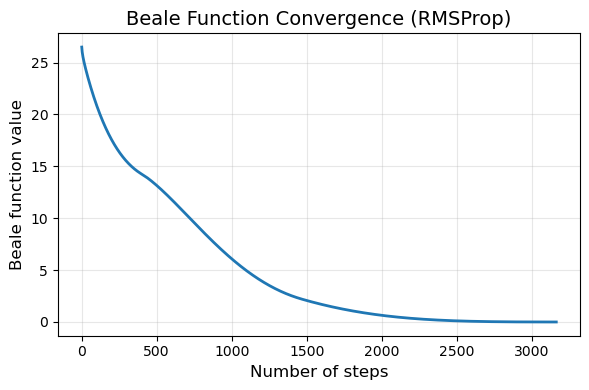

In [746]:
using PyPlot

plt.figure(figsize=(6, 4))
plt.plot(opt.z_history, linewidth=2)
plt.title("Beale Function Convergence (RMSProp)", fontsize=14)
plt.xlabel("Number of steps", fontsize=12)
plt.ylabel("Beale function value", fontsize=12)
plt.grid(true, alpha=0.3)
plt.tight_layout()
plt.show()

In [748]:
using PyPlot

# putting together the points to plot in a 3D plot
number_of_points = 50
margin = 4.5
x_min = 0.0 - margin
x_max = 0.0 + margin
y_min = 0.0 - margin
y_max = 0.0 + margin

#creating the points and the meshgrid
x_points = range(x_min, x_max, length=number_of_points)
y_points = range(y_min, y_max, length=number_of_points)
x_mesh, y_mesh = meshgrid(x_points, y_points)

z = [f(x_mesh[i, j], y_mesh[i, j]) for i in 1:number_of_points, j in 1:number_of_points]

50×50 Matrix{Float64}:
      1.81854e5  142748.0        …      1.31968e5       1.69681e5
      1.67385e5       1.31398e5         1.21327e5       1.56013e5
      1.53517e5       1.20518e5         1.11133e5       1.42918e5
      1.40248e5       1.10109e5         1.01387e5  130398.0
      1.27579e5       1.00169e5     92087.5             1.18451e5
      1.15509e5   90700.1        …  83235.3             1.07079e5
      1.04039e5   81700.9           74830.5         96280.0
  93169.2         73171.9           66872.9         86055.1
  82898.7         65112.9           59362.5         76404.0
  73227.9         57524.1           52299.5         67326.8
  64156.8         50405.4        …  45683.6         58823.5
  55685.3         43756.8           39515.0         50894.1
  47813.5         37578.4           33793.7         43538.5
      ⋮                          ⋱                 
  53634.5         41951.4           42025.5         53722.2
  61954.1         48466.3           48380.0         618

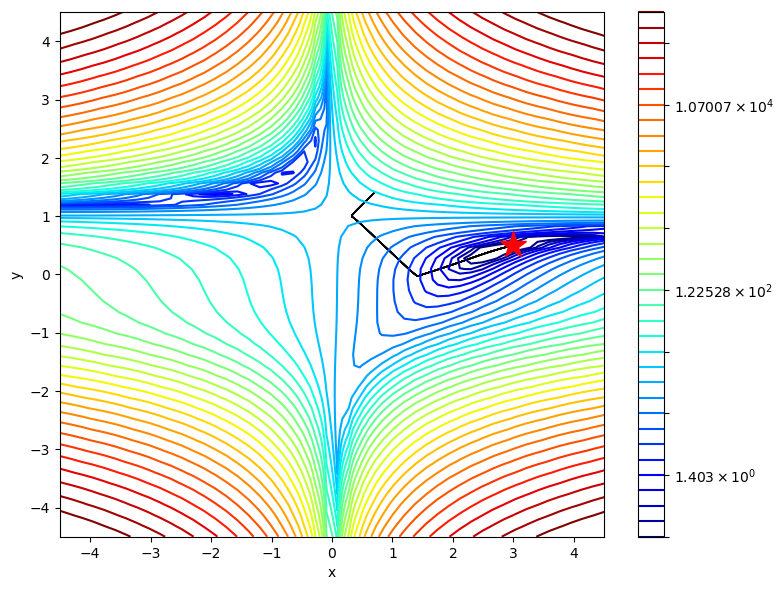

In [750]:
using PyPlot
using PyCall

#lognorm
@pyimport matplotlib.colors as mcolors

path = opt.path

fig, ax = plt.subplots(figsize=(8, 6))

#contour levels and plot
levels = 10 .^ range(-0.5, 5, length=35)
contour = ax.contour(x_mesh, y_mesh, z, 
                     levels=levels,
                     norm=mcolors.LogNorm(), 
                     cmap=plt.cm.jet)

#min
ax.plot(minima[1], minima[2], 
        "r*", markersize=20)

# quiver plot for the optimization path with arrows
if size(path, 2) > 1
    x_start = path[1, 1:end-1]
    y_start = path[2, 1:end-1]
    
    u = path[1, 2:end] .- path[1, 1:end-1]
    v = path[2, 2:end] .- path[2, 1:end-1]
    
    ax.quiver(x_start, y_start, u, v,
              scale_units="xy", 
              angles="xy", 
              scale=1, 
              color="k",
              width=0.003,
              headwidth=3)
end

ax.set_xlabel("x")
ax.set_ylabel("y")

ax.set_xlim((x_min, x_max))
ax.set_ylim((y_min, y_max))
plt.colorbar(contour)
plt.tight_layout()
plt.show()

### Adadelta

Adadelta refines RMSprop even more by eliminating the need for a global learning rate. It uses the ratio of running averages of parameter updates and gradients:

$$
\Delta \theta_t =
-
\frac{\text{RMS}[\Delta \theta]_{t-1}}{\text{RMS}[g]_t}
g_t
$$

This formulation ensures: unit-consistent updates, robustness to hyperparameter choices, stable convergence behavior.
Adadelta adapts automatically to the scale of the gradients and parameters.

In [702]:
using Random

mutable struct AdadeltaOptimizer
    f::Function
    g::Function
    vars::Vector{Float64}
    rho::Float64  # Decay rate (replaces learning_rate in signature)
    epsilon::Float64
    grads_squared_avg::Vector{Float64}  # E[g²] - average of squared gradients
    delta_squared_avg::Vector{Float64}  # E[Δx²] - average of squared parameter updates
    z_history::Vector{Float64}
    x_history::Vector{Float64}
    y_history::Vector{Float64}
    grads::Vector{Float64}
    z::Float64
    path::Matrix{Float64}
    
    function AdadeltaOptimizer(function_, gradients_;
                               x_init=nothing, y_init=nothing, 
                               rho=0.95, epsilon=1e-6)
        scale = 3.0
        vars = zeros(2)
        
        if x_init !== nothing
            vars[1] = x_init
        else
            vars[1] = rand() * 2scale - scale  # Uniform in [-scale, scale]
        end
        
        if y_init !== nothing
            vars[2] = y_init
        else
            vars[2] = rand() * 2scale - scale
        end
        
        println("x_init: ", round(vars[1], digits=3))
        println("y_init: ", round(vars[2], digits=3))
        
        # Initialize accumulators
        grads_squared_avg = zeros(2)  # E[g²]_0 = 0
        delta_squared_avg = zeros(2)  # E[Δx²]_0 = 0
        
        new(function_, gradients_, vars, rho, epsilon, 
            grads_squared_avg, delta_squared_avg,
            Float64[], Float64[], Float64[], zeros(2), 0.0, zeros(2, 0))
    end
end

# Property getters
x(opt::AdadeltaOptimizer) = opt.vars[1]
y(opt::AdadeltaOptimizer) = opt.vars[2]
dx(opt::AdadeltaOptimizer) = opt.grads[1]
dy(opt::AdadeltaOptimizer) = opt.grads[2]

function func(opt::AdadeltaOptimizer, variables::Vector{Float64})
    """Beale function"""
    x_val, y_val = variables
    return opt.f(x_val, y_val)
end

function gradients(opt::AdadeltaOptimizer, variables::Vector{Float64})
    """Gradient of Beale function"""
    x_val, y_val = variables
    return opt.g(x_val, y_val)
end

function weights_update!(opt::AdadeltaOptimizer, grads::Vector{Float64})
    """Weights update using Adadelta """
    # first, an update of the average of squared gradients
    opt.grads_squared_avg = opt.rho * opt.grads_squared_avg .+ 
                           (1.0 - opt.rho) .* grads.^2
    
    rms_grad = sqrt.(opt.grads_squared_avg .+ opt.epsilon)
    
    #RMS of previous parameter updates
    rms_delta = sqrt.(opt.delta_squared_avg .+ opt.epsilon)
    
    #parameter update 
    delta_x = -(rms_delta ./ rms_grad) .* grads
    
    #Apply update
    opt.vars = opt.vars .+ delta_x
    
    # Update average of squared parameter updates
    opt.delta_squared_avg = opt.rho * opt.delta_squared_avg .+ 
                           (1.0 - opt.rho) .* delta_x.^2
end

function history_update!(opt::AdadeltaOptimizer, z::Float64, x_val::Float64, y_val::Float64)
    push!(opt.z_history, z)
    push!(opt.x_history, x_val)
    push!(opt.y_history, y_val)
end

function train!(opt::AdadeltaOptimizer, max_steps::Int)
    """optimizer for max_steps iterations"""
    pre_z = 0.0
    
    println("steps: 0  z: ", round(func(opt, opt.vars), digits=6),
            "  x: ", round(x(opt), digits=5),
            "  y: ", round(y(opt), digits=5))
    
    file = open("adadelta.txt", "w")
    write(file, "$(x(opt))  $(y(opt))\n")
    
    for step in 1:max_steps
        opt.z = func(opt, opt.vars)
        history_update!(opt, opt.z, x(opt), y(opt))
        
        opt.grads = gradients(opt, opt.vars)
        weights_update!(opt, opt.grads)
        
        write(file, "$(x(opt))  $(y(opt))\n")
        
        if step % 100 == 0
            println("steps: $step  z: ", round(func(opt, opt.vars), digits=6),
                    "  x: ", round(x(opt), digits=5),
                    "  y: ", round(y(opt), digits=5),
                    "  dx: ", round(dx(opt), digits=5),
                    "  dy: ", round(dy(opt), digits=5))
        end
        if abs(pre_z - opt.z) < 1e-7
            println("Enough convergence")
            println("steps: $step  z: ", round(func(opt, opt.vars), digits=6),
                    "  x: ", round(x(opt), digits=5),
                    "  y: ", round(y(opt), digits=5))
            opt.z = func(opt, opt.vars)
            history_update!(opt, opt.z, x(opt), y(opt))
            break
        end
        pre_z = opt.z
    end
    
    close(file)
    
    opt.path = hcat(opt.x_history, opt.y_history)'
end

train! (generic function with 9 methods)

In [704]:
#with the same specific initialization
opt = AdadeltaOptimizer(f, gradients; 
                       x_init=0.7, y_init=1.4, 
                       rho=0.95)  
# Note: for Adadelta there is no learning rate parameter

x_init: 0.7
y_init: 1.4


AdadeltaOptimizer(f, gradients, [0.7, 1.4], 0.95, 1.0e-6, [0.0, 0.0], [0.0, 0.0], Float64[], Float64[], Float64[], [0.0, 0.0], 0.0, Matrix{Float64}(undef, 2, 0))

In [706]:
# max 10000 iterations
@time train!(opt, 10000)

steps: 0  z: 26.496662  x: 0.7  y: 1.4
steps: 100  z: 15.603343  x: 0.45143  y: 1.10134  dx: 3.2548  dy: 15.28615
steps: 200  z: 12.80682  x: 0.49456  y: 0.88644  dx: -2.69825  dy: 10.94601
steps: 300  z: 6.710005  x: 1.06958  y: 0.59209  dx: -5.70603  dy: 10.26291
steps: 400  z: 1.664752  x: 1.70877  y: 0.3432  dx: -3.72404  dy: 4.27603
steps: 500  z: 0.423386  x: 2.07271  y: 0.22665  dx: -1.53375  dy: 0.49669
steps: 600  z: 0.201468  x: 2.27554  y: 0.26336  dx: -0.75801  dy: -0.11689
steps: 700  z: 0.085346  x: 2.46871  y: 0.33835  dx: -0.42366  dy: -0.0185
steps: 800  z: 0.030277  x: 2.64741  y: 0.40277  dx: -0.17349  dy: -0.10996
steps: 900  z: 0.023336  x: 2.78525  y: 0.46975  dx: 0.22098  dy: -1.01041
steps: 1000  z: 0.051093  x: 2.82  y: 0.49998  dx: 0.55961  dy: -1.93231
steps: 1100  z: 0.053283  x: 2.82037  y: 0.50121  dx: 0.57992  dy: -1.9857
steps: 1200  z: 0.053582  x: 2.81961  y: 0.50114  dx: 0.58163  dy: -1.99017
steps: 1300  z: 0.053855  x: 2.81887  y: 0.50106  dx: 0.583

2×10000 adjoint(::Matrix{Float64}) with eltype Float64:
 0.7  0.695528  0.691044  0.686581  0.682157  …  2.80588   2.78184   2.80588
 1.4  1.39553   1.39104   1.38656   1.38211      0.374428  0.497321  0.374425

In [708]:
println("Global minima")
println("x*: ", round(minima[1], digits=2), "  y*: ", round(minima[2], digits=2))

println("\nSolution using Adadelta optimization")
println("x: ", round(x(opt), digits=4), "  y: ", round(y(opt), digits=4))

Global minima
x*: 3.0  y*: 0.5

Solution using Adadelta optimization
x: 2.7818  y: 0.4973


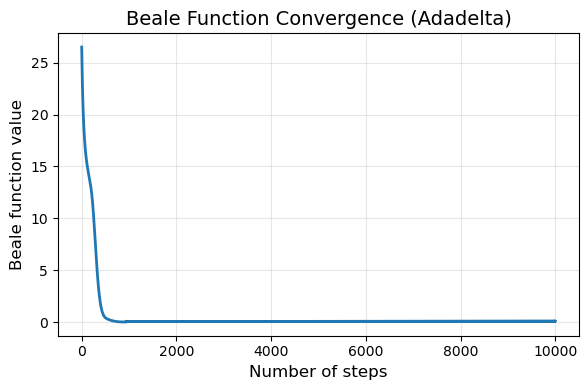

In [710]:
using PyPlot

plt.figure(figsize=(6, 4))
plt.plot(opt.z_history, linewidth=2)
plt.title("Beale Function Convergence (Adadelta)", fontsize=14)
plt.xlabel("Number of steps", fontsize=12)
plt.ylabel("Beale function value", fontsize=12)
plt.grid(true, alpha=0.3)
plt.tight_layout()
plt.show()

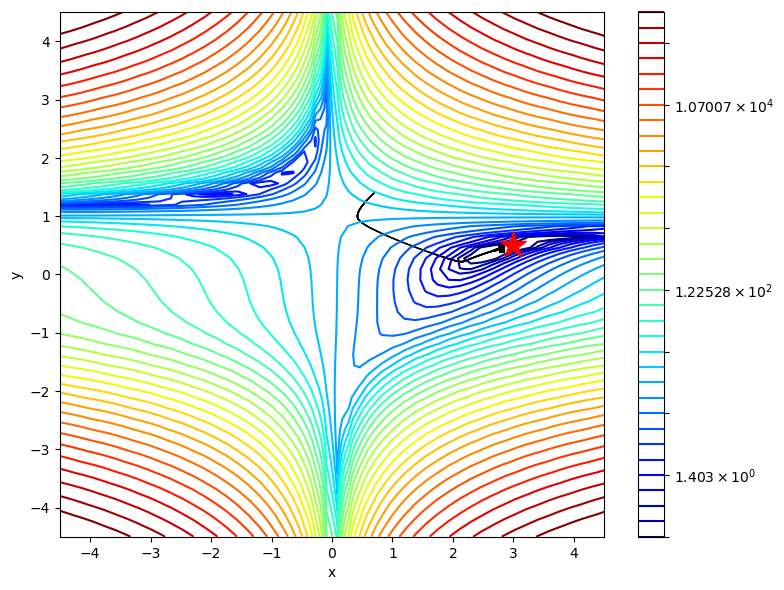

In [712]:
using PyPlot
using PyCall

#LogNorm
@pyimport matplotlib.colors as mcolors

#path from the Adadelta optimizer
path = opt.path

fig, ax = plt.subplots(figsize=(8, 6))

#contour levels 
levels = 10 .^ range(-0.5, 5, length=35)
contour = ax.contour(x_mesh, y_mesh, z, 
                     levels=levels,
                     norm=mcolors.LogNorm(), 
                     cmap=plt.cm.jet)

#min
ax.plot(minima[1], minima[2], 
        "r*", markersize=20)

#plot for the optimization path
if size(path, 2) > 1
    x_start = path[1, 1:end-1]
    y_start = path[2, 1:end-1]

    u = path[1, 2:end] .- path[1, 1:end-1]
    v = path[2, 2:end] .- path[2, 1:end-1]
    
    ax.quiver(x_start, y_start, u, v,
              scale_units="xy", 
              angles="xy", 
              scale=1, 
              color="k",
              width=0.003,
              headwidth=3)
end

ax.set_xlabel("x")
ax.set_ylabel("y")

ax.set_xlim((x_min, x_max))
ax.set_ylim((y_min, y_max))
plt.colorbar(contour)
plt.tight_layout()
plt.show()

### Adamax


AdaMax is a variant of Adam that replaces the ( $\ell_2$ )  norm with the $\ell_\infty$  norm:
$$
u_t = \max(\beta_2 v_{t-1}, |g_t|)
$$

The update rule becomes:
$$
\theta_{t+1} = \theta_t - \frac{\eta}{u_t} \hat{m}_t
$$

This formulation improves numerical stability and removes the need for bias correction on the second moment.

In [714]:
using Random

mutable struct AdamaxOptimizer
    f::Function
    g::Function
    vars::Vector{Float64}
    lr::Float64
    beta1::Float64
    beta2::Float64
    epsilon::Float64
    m::Vector{Float64}        # First moment vector
    u::Vector{Float64}        # Infinity norm vector
    z_history::Vector{Float64}
    x_history::Vector{Float64}
    y_history::Vector{Float64}
    grads::Vector{Float64}
    z::Float64
    path::Matrix{Float64}
    
    function AdamaxOptimizer(function_, gradients_;
                             x_init=nothing, y_init=nothing,
                             learning_rate=0.002, beta1=0.9, beta2=0.999, epsilon=1e-8)
        scale = 3.0
        vars = zeros(2)
        
        if x_init !== nothing
            vars[1] = x_init
        else
            vars[1] = rand() * 2scale - scale  # Uniform in [-scale, scale]
        end
        
        if y_init !== nothing
            vars[2] = y_init
        else
            vars[2] = rand() * 2scale - scale
        end
        
        println("x_init: ", round(vars[1], digits=3))
        println("y_init: ", round(vars[2], digits=3))
        
        #initializing moment vectors
        m = zeros(2)  
        u = zeros(2)  
        
        new(function_, gradients_, vars, learning_rate, 
            beta1, beta2, epsilon, m, u,
            Float64[], Float64[], Float64[], zeros(2), 0.0, zeros(2, 0))
    end
end

x(opt::AdamaxOptimizer) = opt.vars[1]
y(opt::AdamaxOptimizer) = opt.vars[2]
dx(opt::AdamaxOptimizer) = opt.grads[1]
dy(opt::AdamaxOptimizer) = opt.grads[2]

function func(opt::AdamaxOptimizer, variables::Vector{Float64})
    """Beale function"""
    x_val, y_val = variables
    return opt.f(x_val, y_val)
end

function gradients(opt::AdamaxOptimizer, variables::Vector{Float64})
    """Gradient of Beale function"""
    x_val, y_val = variables
    return opt.g(x_val, y_val)
end

function weights_update!(opt::AdamaxOptimizer, grads::Vector{Float64}, time::Int)
    """Weights update using Adamax """
    opt.m = opt.beta1 * opt.m .+ (1.0 - opt.beta1) .* grads
    
    # Updating the inf norm
    opt.u = max.(opt.beta2 .* opt.u, abs.(grads))
    m_hat = opt.m ./ (1.0 - opt.beta1^time)
    
    # Compute parameter update with adaptive learning rate
    opt.vars = opt.vars .- (opt.lr ./ (1.0 - opt.beta1^time)) .* m_hat ./ (opt.u .+ opt.epsilon)
end

function history_update!(opt::AdamaxOptimizer, z::Float64, x_val::Float64, y_val::Float64)
    push!(opt.z_history, z)
    push!(opt.x_history, x_val)
    push!(opt.y_history, y_val)
end

function train!(opt::AdamaxOptimizer, max_steps::Int)
    """Train the optimizer for max_steps iterations"""
    opt.z_history = Float64[]
    opt.x_history = Float64[]
    opt.y_history = Float64[]
    
    pre_z = 0.0
    println("steps: 0  z: ", round(func(opt, opt.vars), digits=6),
            "  x: ", round(x(opt), digits=5),
            "  y: ", round(y(opt), digits=5))
    
    file = open("adamax.txt", "w")
    write(file, "$(x(opt))  $(y(opt))\n")
    
    for step in 1:max_steps
        opt.z = func(opt, opt.vars)
        history_update!(opt, opt.z, x(opt), y(opt))
        
        opt.grads = gradients(opt, opt.vars)
        weights_update!(opt, opt.grads, step)
        
        write(file, "$(x(opt))  $(y(opt))\n")
        
        if step % 100 == 0
            println("steps: $step  z: ", round(func(opt, opt.vars), digits=6),
                    "  x: ", round(x(opt), digits=5),
                    "  y: ", round(y(opt), digits=5),
                    "  dx: ", round(dx(opt), digits=5),
                    "  dy: ", round(dy(opt), digits=5))
        end
        
        if abs(pre_z - opt.z) < 1e-7
            println("Enough convergence")
            println("steps: $step  z: ", round(func(opt, opt.vars), digits=6),
                    "  x: ", round(x(opt), digits=5),
                    "  y: ", round(y(opt), digits=5))
            opt.z = func(opt, opt.vars)
            history_update!(opt, opt.z, x(opt), y(opt))
            break
        end
        
        pre_z = opt.z
    end
    
    close(file)
    opt.path = hcat(opt.x_history, opt.y_history)'
end

train! (generic function with 9 methods)

In [718]:
# With the same specific initialization as before
opt = AdamaxOptimizer(f, gradients; x_init=0.7, y_init=1.4, learning_rate=0.002, beta1=0.9, beta2=0.999, epsilon=1e-8)

x_init: 0.7
y_init: 1.4


AdamaxOptimizer(f, gradients, [0.7, 1.4], 0.002, 0.9, 0.999, 1.0e-8, [0.0, 0.0], [0.0, 0.0], Float64[], Float64[], Float64[], [0.0, 0.0], 0.0, Matrix{Float64}(undef, 2, 0))

In [786]:
# Max 10000 iterations just like before 
@time train!(opt, 1000)

steps: 0  z: 1.0e-5  x: 2.99654  y: 0.49975
Enough convergence
steps: 2  z: 1.0e-5  x: 2.99674  y: 0.4998
  0.002402 seconds (225 allocations: 110.578 KiB)


2×3171 adjoint(::Matrix{Float64}) with eltype Float64:
 0.7  0.696838  0.694559  0.692659  0.690977  …  2.99654   2.99763   2.99674
 1.4  1.39684   1.39456   1.39265   1.39097      0.499749  0.498771  0.499798

In [788]:
println("Global minima")
println("x*: ", round(minima[1], digits=2), "  y*: ", round(minima[2], digits=2))

println("\nSolution using Adamax optimization")
println("x: ", round(x(opt), digits=4), "  y: ", round(y(opt), digits=4))

Global minima
x*: 3.0  y*: 0.5

Solution using Adamax optimization
x: 2.9967  y: 0.4998


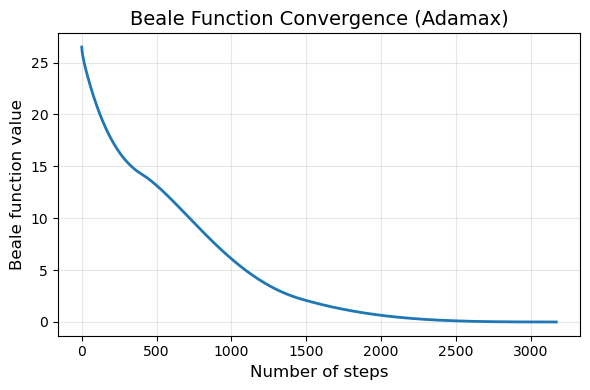

In [790]:
using PyPlot

plt.figure(figsize=(6, 4))
plt.plot(opt.z_history, linewidth=2)
plt.title("Beale Function Convergence (Adamax)", fontsize=14)
plt.xlabel("Number of steps", fontsize=12)
plt.ylabel("Beale function value", fontsize=12)
plt.grid(true, alpha=0.3)
plt.tight_layout()
plt.show()

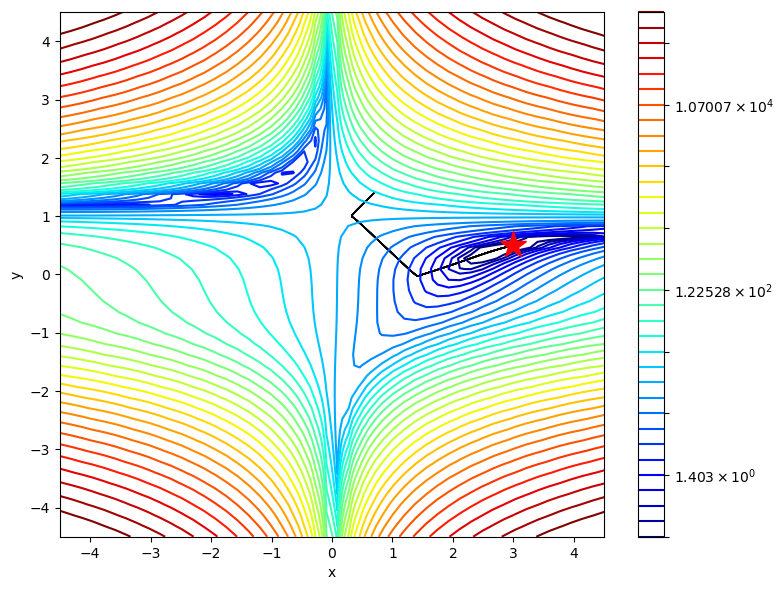

In [792]:
using PyPlot
using PyCall

#log norm
@pyimport matplotlib.colors as mcolors

path = opt.path

#figure
fig, ax = plt.subplots(figsize=(8, 6))

#contour levels
levels = 10 .^ range(-0.5, 5, length=35)
contour = ax.contour(x_mesh, y_mesh, z, 
                     levels=levels,
                     norm=mcolors.LogNorm(), 
                     cmap=plt.cm.jet)

# min point
ax.plot(minima[1], minima[2], 
        "r*", markersize=20)

#plot for the optimization path
if size(path, 2) > 1
    x_start = path[1, 1:end-1]
    y_start = path[2, 1:end-1]
    
    u = path[1, 2:end] .- path[1, 1:end-1]
    v = path[2, 2:end] .- path[2, 1:end-1]
    
    ax.quiver(x_start, y_start, u, v,
              scale_units="xy", 
              angles="xy", 
              scale=1, 
              color="k",
              width=0.003,
              headwidth=3)
end

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_xlim((x_min, x_max))
ax.set_ylim((y_min, y_max))
plt.colorbar(contour)
plt.tight_layout()
plt.show()

### Nadam 


Nadam combines Nesterov momentum with Adam’s adaptive moment estimation. The update incorporates a look-ahead gradient directly into Adam’s momentum term:

$$
\theta_{t+1} =
\theta_t -
\frac{\eta}{\sqrt{\hat{v}_t} + \varepsilon}
\left(
\beta_1 \hat{m}_t +
\frac{(1 - \beta_1)}{1 - \beta_1^t} g_t
\right)
$$

Nadam often converges faster than Adam in practice, especially for deep or highly non-convex problems.

In [794]:
using Random

mutable struct NadamOptimizer
    f::Function
    g::Function
    vars::Vector{Float64}
    lr::Float64
    beta1::Float64
    beta2::Float64
    epsilon::Float64
    m::Vector{Float64}        # First moment vector
    v::Vector{Float64}        # Second moment vector
    z_history::Vector{Float64}
    x_history::Vector{Float64}
    y_history::Vector{Float64}
    grads::Vector{Float64}
    z::Float64
    path::Matrix{Float64}
    
    function NadamOptimizer(function_, gradients_;
                            x_init=nothing, y_init=nothing,
                            learning_rate=0.002, beta1=0.9, beta2=0.999, epsilon=1e-8)
        scale = 3.0
        vars = zeros(2)
        
        if x_init !== nothing
            vars[1] = x_init
        else
            vars[1] = rand() * 2scale - scale  # Uniform in [-scale, scale]
        end
        
        if y_init !== nothing
            vars[2] = y_init
        else
            vars[2] = rand() * 2scale - scale
        end
        
        println("x_init: ", round(vars[1], digits=3))
        println("y_init: ", round(vars[2], digits=3))
        
        # Initialize moment vectors
        m = zeros(2)  # First moment (mean)
        v = zeros(2)  # Second moment (uncentered variance)
        
        new(function_, gradients_, vars, learning_rate, 
            beta1, beta2, epsilon, m, v,
            Float64[], Float64[], Float64[], zeros(2), 0.0, zeros(2, 0))
    end
end

# Property getters
x(opt::NadamOptimizer) = opt.vars[1]
y(opt::NadamOptimizer) = opt.vars[2]
dx(opt::NadamOptimizer) = opt.grads[1]
dy(opt::NadamOptimizer) = opt.grads[2]

function func(opt::NadamOptimizer, variables::Vector{Float64})
    """Beale function"""
    x_val, y_val = variables
    return opt.f(x_val, y_val)
end

function gradients(opt::NadamOptimizer, variables::Vector{Float64})
    """Gradient of Beale function """
    x_val, y_val = variables
    return opt.g(x_val, y_val)
end

function weights_update!(opt::NadamOptimizer, grads::Vector{Float64}, time::Int)
    """Weights update using Nadam (Adam with Nesterov momentum)"""
    opt.m = opt.beta1 * opt.m .+ (1.0 - opt.beta1) .* grads
    
    #Update biased second raw moment estimate
    opt.v = opt.beta2 * opt.v .+ (1.0 - opt.beta2) .* grads.^2
    
    #and compute bias-corrected first moment
    m_hat = (opt.beta1 .* opt.m) ./ (1.0 - opt.beta1^(time+1)) .+ 
            ((1.0 - opt.beta1) .* grads) ./ (1.0 - opt.beta1^time)
    
    #Compute bias-corrected second raw moment
    v_hat = opt.v ./ (1.0 - opt.beta2^time)
    
    #Compute parameter update
    opt.vars = opt.vars .- opt.lr .* m_hat ./ (sqrt.(v_hat) .+ opt.epsilon)
end

function history_update!(opt::NadamOptimizer, z::Float64, x_val::Float64, y_val::Float64)
    push!(opt.z_history, z)
    push!(opt.x_history, x_val)
    push!(opt.y_history, y_val)
end

function train!(opt::NadamOptimizer, max_steps::Int)
    """optimizer for max_steps iterations"""
    # Reset histories
    opt.z_history = Float64[]
    opt.x_history = Float64[]
    opt.y_history = Float64[]
    
    pre_z = 0.0
    println("steps: 0  z: ", round(func(opt, opt.vars), digits=6),
            "  x: ", round(x(opt), digits=5),
            "  y: ", round(y(opt), digits=5))
    
    # Open file for writing
    file = open("nadam.txt", "w")
    write(file, "$(x(opt))  $(y(opt))\n")
    
    for step in 1:max_steps
        opt.z = func(opt, opt.vars)
        history_update!(opt, opt.z, x(opt), y(opt))
        
        opt.grads = gradients(opt, opt.vars)
        weights_update!(opt, opt.grads, step)
        
        write(file, "$(x(opt))  $(y(opt))\n")
        
        if step % 100 == 0
            println("steps: $step  z: ", round(func(opt, opt.vars), digits=6),
                    "  x: ", round(x(opt), digits=5),
                    "  y: ", round(y(opt), digits=5),
                    "  dx: ", round(dx(opt), digits=5),
                    "  dy: ", round(dy(opt), digits=5))
        end
        
        if abs(pre_z - opt.z) < 1e-7
            println("Enough convergence")
            println("steps: $step  z: ", round(func(opt, opt.vars), digits=6),
                    "  x: ", round(x(opt), digits=5),
                    "  y: ", round(y(opt), digits=5))
            opt.z = func(opt, opt.vars)
            history_update!(opt, opt.z, x(opt), y(opt))
            break
        end
        
        pre_z = opt.z
    end
    
    close(file)
    
    opt.path = hcat(opt.x_history, opt.y_history)'
end

train! (generic function with 9 methods)

In [796]:
#specific initialization same as before 
opt = NadamOptimizer(f, gradients; 
                    x_init=0.7, y_init=1.4, 
                    learning_rate=0.002, beta1=0.9, beta2=0.999, epsilon=1e-8)


x_init: 0.7
y_init: 1.4


NadamOptimizer(f, gradients, [0.7, 1.4], 0.002, 0.9, 0.999, 1.0e-8, [0.0, 0.0], [0.0, 0.0], Float64[], Float64[], Float64[], [0.0, 0.0], 0.0, Matrix{Float64}(undef, 2, 0))

In [798]:
#train with 10000 iterations max
@time train!(opt, 10000)

steps: 0  z: 26.496662  x: 0.7  y: 1.4
steps: 100  z: 18.326741  x: 0.52956  y: 1.2233  dx: 8.38336  dy: 22.92754
steps: 200  z: 15.44964  x: 0.43274  y: 1.09481  dx: 2.98334  dy: 14.40328
steps: 300  z: 14.080223  x: 0.40114  y: 0.98884  dx: -0.27842  dy: 10.92243
steps: 400  z: 12.986017  x: 0.43763  y: 0.88871  dx: -2.69598  dy: 9.80495
steps: 500  z: 11.55279  x: 0.54454  y: 0.78302  dx: -4.5966  dy: 9.67477
steps: 600  z: 9.573867  x: 0.71061  y: 0.66893  dx: -5.86203  dy: 9.39353
steps: 700  z: 7.317041  x: 0.90903  y: 0.5535  dx: -6.32894  dy: 8.38683
steps: 800  z: 5.235733  x: 1.1118  y: 0.44722  dx: -6.09749  dy: 6.84306
steps: 900  z: 3.595419  x: 1.30124  y: 0.3571  dx: -5.44589  dy: 5.19144
steps: 1000  z: 2.427608  x: 1.4697  y: 0.28553  dx: -4.62846  dy: 3.70225
steps: 1100  z: 1.648866  x: 1.6153  y: 0.23206  dx: -3.80623  dy: 2.4691
steps: 1200  z: 1.151245  x: 1.73897  y: 0.19504  dx: -3.06315  dy: 1.49678
steps: 1300  z: 0.840386  x: 1.84292  y: 0.17231  dx: -2.43476

2×6652 adjoint(::Matrix{Float64}) with eltype Float64:
 0.7  0.697053  0.694745  0.692599  0.690517  …  2.98709   2.98711   2.98714
 1.4  1.39705   1.39474   1.3926    1.39051      0.496743  0.496749  0.496755

In [799]:
println("Global minima")
println("x*: ", round(minima[1], digits=2), "  y*: ", round(minima[2], digits=2))

println("\nSolution using Nadam optimization")
println("x: ", round(x(opt), digits=4), "  y: ", round(y(opt), digits=4))

Global minima
x*: 3.0  y*: 0.5

Solution using Nadam optimization
x: 2.9871  y: 0.4968


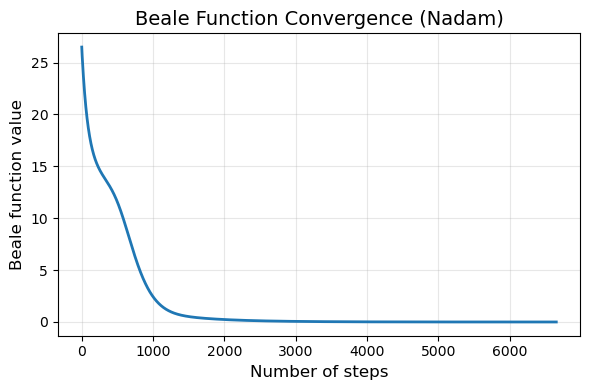

In [800]:
using PyPlot

plt.figure(figsize=(6, 4))
plt.plot(opt.z_history, linewidth=2)
plt.title("Beale Function Convergence (Nadam)", fontsize=14)
plt.xlabel("Number of steps", fontsize=12)
plt.ylabel("Beale function value", fontsize=12)
plt.grid(true, alpha=0.3)
plt.tight_layout()
plt.show()

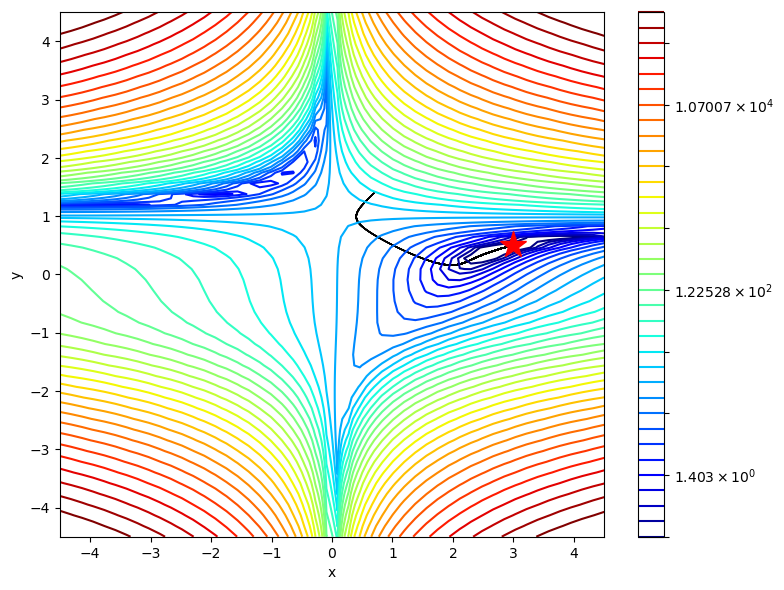

In [801]:
using PyPlot
using PyCall

#LogNorm
@pyimport matplotlib.colors as mcolors

path = opt.path
fig, ax = plt.subplots(figsize=(8, 6))

# contour levels and plot
levels = 10 .^ range(-0.5, 5, length=35)
contour = ax.contour(x_mesh, y_mesh, z, 
                     levels=levels,
                     norm=mcolors.LogNorm(), 
                     cmap=plt.cm.jet)

#min point
ax.plot(minima[1], minima[2], 
        "r*", markersize=20)

#Createplot for the optimization path
if size(path, 2) > 1
    x_start = path[1, 1:end-1]
    y_start = path[2, 1:end-1]
    
    u = path[1, 2:end] .- path[1, 1:end-1]
    v = path[2, 2:end] .- path[2, 1:end-1]
    
    ax.quiver(x_start, y_start, u, v,
              scale_units="xy", 
              angles="xy", 
              scale=1, 
              color="k",
              width=0.003,
              headwidth=3)
end

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_xlim((x_min, x_max))
ax.set_ylim((y_min, y_max))
plt.colorbar(contour)

plt.tight_layout()
plt.show()

### Comparaison

In [803]:
#define the common starting point
x_init_val = 0.7
y_init_val = 1.4

#create optimizer instances
momentum = MomentumOptimizer(f, gradients; 
                             x_init=x_init_val, y_init=y_init_val, 
                             learning_rate=0.005, momentum=0.9)

nesterov = NesterovMomentumOptimizer(f, gradients; 
                                     x_init=x_init_val, y_init=y_init_val, 
                                     learning_rate=0.005, momentum=0.9)

adagrad = AdagradOptimizer(f, gradients; 
                           x_init=x_init_val, y_init=y_init_val, 
                           learning_rate=0.1)

rmsprop = RMSPropOptimizer(f, gradients; 
                           x_init=x_init_val, y_init=y_init_val, 
                           learning_rate=0.1, decay=0.9, epsilon=1e-10)

adam = AdamOptimizer(f, gradients; 
                     x_init=x_init_val, y_init=y_init_val, 
                     learning_rate=0.1, beta1=0.9, beta2=0.999, epsilon=1e-8)

#add the new optimizers we just created
adadelta = AdadeltaOptimizer(f, gradients; 
                             x_init=x_init_val, y_init=y_init_val, 
                             rho=0.95, epsilon=1e-6)

adamax = AdamaxOptimizer(f, gradients; 
                         x_init=x_init_val, y_init=y_init_val, 
                         learning_rate=0.002, beta1=0.9, beta2=0.999, epsilon=1e-8)

nadam = NadamOptimizer(f, gradients; 
                       x_init=x_init_val, y_init=y_init_val, 
                       learning_rate=0.002, beta1=0.9, beta2=0.999, epsilon=1e-8)

#storing it in arrays (including the new optimizers)
optimizers = [momentum, nesterov, adagrad, rmsprop, adam, adadelta, adamax, nadam]
opt_names = ["momentum", "nesterov", "adagrad", "rmsprop", "adam", "adadelta", "adamax", "nadam"]

x_init: 0.7
y_init: 1.4
x_init: 0.7
y_init: 1.4
x_init: 0.7
y_init: 1.4
x_init: 0.7
y_init: 1.4
x_init: 0.7
y_init: 1.4
x_init: 0.7
y_init: 1.4
x_init: 0.7
y_init: 1.4
x_init: 0.7
y_init: 1.4


8-element Vector{String}:
 "momentum"
 "nesterov"
 "adagrad"
 "rmsprop"
 "adam"
 "adadelta"
 "adamax"
 "nadam"

In [805]:
all_paths = []

for (opt, name) in zip(optimizers, opt_names)
    println("\n Training with $name ")
    
    opt.vars[1] = 0.8  
    opt.vars[2] = 1.6  
    
    if name in ["momentum", "nesterov"]
        opt.velocity = zeros(2)
    elseif name == "adagrad"
        opt.grads_squared = zeros(2) .+ 0.1 
    elseif name == "rmsprop"
        opt.grads_squared = zeros(2)
    elseif name == "adam"
        opt.grads_first_moment = zeros(2)
        opt.grads_second_moment = zeros(2)
    elseif name == "adadelta"
        opt.grads_squared_avg = zeros(2)  
        opt.delta_squared_avg = zeros(2)  
    elseif name == "adamax"
        opt.m = zeros(2)  #first moment
        opt.u = zeros(2)  #and infinity norm
    elseif name == "nadam"
        opt.m = zeros(2)  #first moment
        opt.v = zeros(2)  #second moment
    end
    
    opt.z_history = Float64[]
    opt.x_history = Float64[]
    opt.y_history = Float64[]
    
    z_prev = 0.0
    max_steps = 10000
    
    for step in 1:max_steps
        current_z = f(opt.vars[1], opt.vars[2])
        
        push!(opt.z_history, current_z)
        push!(opt.x_history, opt.vars[1])
        push!(opt.y_history, opt.vars[2])
        
        grads = gradients(opt.vars[1], opt.vars[2])
        
        if name == "sgd"
            # simple gradient descent
            opt.vars = opt.vars .- opt.lr .* grads
        elseif name == "momentum"
            #momentum update
            opt.velocity = opt.momentum * opt.velocity - opt.lr * grads
            opt.vars = opt.vars + opt.velocity
        elseif name == "nesterov"
            #nesterov momentum update
            x_ahead = opt.vars[1] + opt.momentum * opt.velocity[1]
            y_ahead = opt.vars[2] + opt.momentum * opt.velocity[2]
            grads_ahead = gradients(x_ahead, y_ahead)
            opt.velocity = opt.momentum * opt.velocity - opt.lr * grads_ahead
            opt.vars = opt.vars + opt.velocity
        elseif name == "adagrad"
            #adagrad update
            opt.grads_squared = opt.grads_squared + grads.^2
            opt.vars = opt.vars - opt.lr * grads ./ (sqrt.(opt.grads_squared) .+ opt.epsilon)
        elseif name == "rmsprop"
            #RMSProp update
            opt.grads_squared = opt.decay * opt.grads_squared .+ 
                               (1.0 - opt.decay) .* grads.^2
            opt.vars = opt.vars .- opt.lr .* grads ./ 
                       (sqrt.(opt.grads_squared) .+ opt.epsilon)
        elseif name == "adam"
            #Adam update
            time = step
            opt.grads_first_moment = opt.beta1 * opt.grads_first_moment .+ 
                                    (1.0 - opt.beta1) .* grads
            opt.grads_second_moment = opt.beta2 * opt.grads_second_moment .+ 
                                     (1.0 - opt.beta2) .* grads.^2
            
            grads_first_moment_unbiased = opt.grads_first_moment ./ (1.0 - opt.beta1^time)
            grads_second_moment_unbiased = opt.grads_second_moment ./ (1.0 - opt.beta2^time)
            
            opt.vars = opt.vars .- opt.lr .* grads_first_moment_unbiased ./
                       (sqrt.(grads_second_moment_unbiased) .+ opt.epsilon)
        elseif name == "adadelta"
            #Adadelta update
            #Update average of squared gradients
            opt.grads_squared_avg = opt.rho * opt.grads_squared_avg .+ 
                                   (1.0 - opt.rho) .* grads.^2
            
            #compute RMS of gradients
            rms_grad = sqrt.(opt.grads_squared_avg .+ opt.epsilon)
            
            #compute RMS of previous parameter updates
            rms_delta = sqrt.(opt.delta_squared_avg .+ opt.epsilon)
            
            # compute parameter update
            delta_x = -(rms_delta ./ rms_grad) .* grads
            
            # apply update
            opt.vars = opt.vars .+ delta_x
            
            # update average of squared parameter updates
            opt.delta_squared_avg = opt.rho * opt.delta_squared_avg .+ 
                                   (1.0 - opt.rho) .* delta_x.^2
        elseif name == "adamax"
            # adamax update (Adam with infinity norm)
            time = step
            # update biased first moment estimate
            opt.m = opt.beta1 * opt.m .+ (1.0 - opt.beta1) .* grads
            
            # update the exponentially weighted infinity norm
            opt.u = max.(opt.beta2 .* opt.u, abs.(grads))
            
            # Compute bias-corrected first moment estimate
            m_hat = opt.m ./ (1.0 - opt.beta1^time)
            
            # compute parameter update with adaptive learning rate
            opt.vars = opt.vars .- (opt.lr ./ (1.0 - opt.beta1^time)) .* m_hat ./ (opt.u .+ opt.epsilon)
        elseif name == "nadam"
            # nadam update (Adam with Nesterov momentum)
            time = step
            # update biased first moment estimate
            opt.m = opt.beta1 * opt.m .+ (1.0 - opt.beta1) .* grads
            
            # update biased second raw moment estimate
            opt.v = opt.beta2 * opt.v .+ (1.0 - opt.beta2) .* grads.^2
            
            # compute bias-corrected first moment (with Nesterov)
            m_hat = (opt.beta1 .* opt.m) ./ (1.0 - opt.beta1^(time+1)) .+ 
                   ((1.0 - opt.beta1) .* grads) ./ (1.0 - opt.beta1^time)
            
            # compute bias-corrected second raw moment
            v_hat = opt.v ./ (1.0 - opt.beta2^time)
            
            # compute parameter update
            opt.vars = opt.vars .- opt.lr .* m_hat ./ (sqrt.(v_hat) .+ opt.epsilon)
        end
        
        if abs(z_prev - current_z) < 1e-6
            println("Converged at step $step")
            break
        end
        
        z_prev = current_z
    end
    
    path = hcat(opt.x_history, opt.y_history)'
    push!(all_paths, path)
    
    println("$name training done!")
    println("  Steps: $(length(opt.z_history))")
    println("  Final: x = $(round(opt.vars[1], digits=5)), y = $(round(opt.vars[2], digits=5))")
    println("  f(x,y) = $(round(f(opt.vars[1], opt.vars[2]), digits=6))")
end


 Training with momentum 
Converged at step 298
momentum training done!
  Steps: 298
  Final: x = 3.01301, y = 0.50323
  f(x,y) = 2.7e-5

 Training with nesterov 
Converged at step 271
nesterov training done!
  Steps: 271
  Final: x = 3.01308, y = 0.50325
  f(x,y) = 2.7e-5

 Training with adagrad 
Converged at step 6012
adagrad training done!
  Steps: 6012
  Final: x = 2.90432, y = 0.47499
  f(x,y) = 0.001635

 Training with rmsprop 
rmsprop training done!
  Steps: 10000
  Final: x = 2.77376, y = 0.49764
  f(x,y) = 0.07525

 Training with adam 
Converged at step 469
adam training done!
  Steps: 469
  Final: x = 2.98351, y = 0.49584
  f(x,y) = 4.4e-5

 Training with adadelta 
adadelta training done!
  Steps: 10000
  Final: x = 2.80968, y = 0.37677
  f(x,y) = 0.090087

 Training with adamax 
Converged at step 5267
adamax training done!
  Steps: 5267
  Final: x = 2.96696, y = 0.49159
  f(x,y) = 0.000182

 Training with nadam 
Converged at step 7017
nadam training done!
  Steps: 7017
  Fin

In [807]:
using PyPlot

number_of_points = 50
margin = 4.5
x_min = 0.0 - margin
x_max = 0.0 + margin
y_min = 0.0 - margin
y_max = 0.0 + margin

x_points = range(x_min, x_max, length=number_of_points)
y_points = range(y_min, y_max, length=number_of_points)

x_mesh, y_mesh = meshgrid(x_points, y_points)

z = [f(x_mesh[i, j], y_mesh[i, j]) for i in 1:number_of_points, j in 1:number_of_points]

50×50 Matrix{Float64}:
      1.81854e5  142748.0        …      1.31968e5       1.69681e5
      1.67385e5       1.31398e5         1.21327e5       1.56013e5
      1.53517e5       1.20518e5         1.11133e5       1.42918e5
      1.40248e5       1.10109e5         1.01387e5  130398.0
      1.27579e5       1.00169e5     92087.5             1.18451e5
      1.15509e5   90700.1        …  83235.3             1.07079e5
      1.04039e5   81700.9           74830.5         96280.0
  93169.2         73171.9           66872.9         86055.1
  82898.7         65112.9           59362.5         76404.0
  73227.9         57524.1           52299.5         67326.8
  64156.8         50405.4        …  45683.6         58823.5
  55685.3         43756.8           39515.0         50894.1
  47813.5         37578.4           33793.7         43538.5
      ⋮                          ⋱                 
  53634.5         41951.4           42025.5         53722.2
  61954.1         48466.3           48380.0         618

Saved plot to: all_optimizers_comparison.png


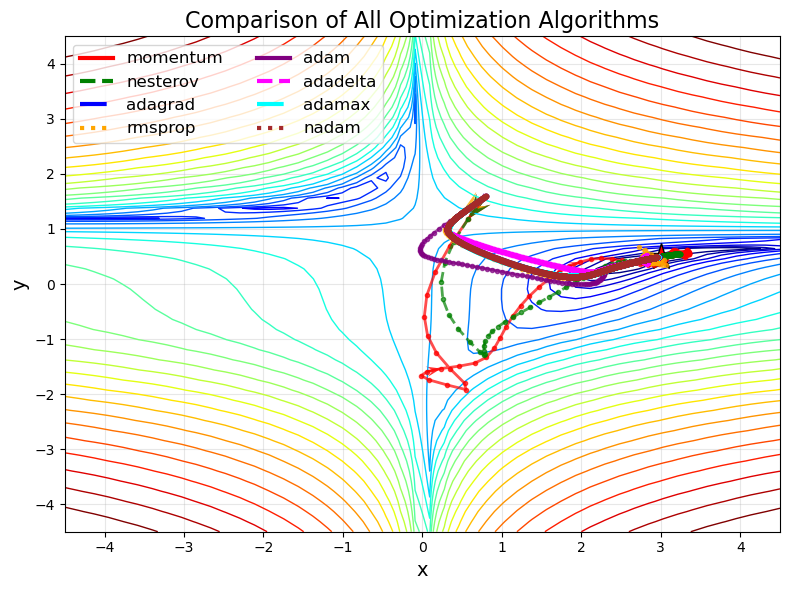

In [817]:
using PyPlot
using PyCall

@pyimport matplotlib.colors as mcolors

fig, ax = plt.subplots(figsize=(8, 6))  

levels = 10 .^ range(-0.5, 5, length=25)

contour = ax.contour(x_mesh, y_mesh, z, 
                     levels=levels,
                     norm=mcolors.LogNorm(), 
                     cmap=plt.cm.jet,
                     linewidths=1.0)

ax.plot(minima[1], minima[2], 
        "r*", markersize=20, markeredgecolor="black", markeredgewidth=1)

colors = ["red", "green", "blue", "orange", "purple", "magenta", "cyan", "brown"]

line_styles = ["-", "--", "-.", ":", "-", "--", "-.", ":"]

for (name, path, color, ls) in zip(opt_names, all_paths, colors, line_styles)
    if size(path, 2) > 1
        ax.plot(path[1,:], path[2,:], 
                color=color, linestyle=ls, linewidth=2,
                marker="o", markersize=3, alpha=0.7)
        
        x_start = path[1, 1:end-1]
        y_start = path[2, 1:end-1]
        
        u = path[1, 2:end] .- path[1, 1:end-1]
        v = path[2, 2:end] .- path[2, 1:end-1]
        
        n = max(1, div(size(path, 2) - 1, 20))  # show every 20th arrow
        idxs = 1:n:size(path, 2)-1
        
        if length(idxs) > 0
            ax.quiver(x_start[idxs], y_start[idxs], u[idxs], v[idxs],
                      scale_units="xy", 
                      angles="xy", 
                      scale=1, 
                      color=color,
                      width=0.005,
                      headwidth=5,
                      headlength=7,
                      alpha=0.8)
        end
        
        ax.plot([], [], color=color, linestyle=ls, label=name, lw=3)
    end
end

ax.set_xlabel("x", fontsize=14)
ax.set_ylabel("y", fontsize=14)
ax.set_title("Comparison of All Optimization Algorithms", fontsize=16)

ax.set_xlim((x_min, x_max))
ax.set_ylim((y_min, y_max))

ax.grid(true, alpha=0.3)
ax.legend(loc="upper left", prop=Dict("size" => 12), ncol=2)

plt.savefig("all_optimizers_comparison.png", dpi=200, bbox_inches="tight")
println("Saved plot to: all_optimizers_comparison.png")

plt.tight_layout()
plt.show()

### Results : 

The algorithms implemented on the Beale function highlight clear differences in behavior between all the gradient-based optimization methods. 

Adaptive learning-rate methodsuch as  (Adagrad, RMSprop, Adadelt anda, Adm) general 
- converge far than vanilla gradient descent and momentum-based methods because they scale the learning rate according to past gradients. These algorithms are also more adapted tondle ill-conditioned probt and are more effective at navigating narrow valleys and regions vith different curvatures.   tly.

Momentum-based methods improve directional stability but remain sensitive to hyperpara   eters.

Among all thods, **Adam and itsariants** often provide the best trade-off between speed, stability, and eas

Based on the article : 
" In summary, RMSprop is an extension of Adagrad that deals with its radically diminishing learning
rates. It is identical to Adadelta, except that Adadelta uses the RMS of parameter updates in the
numerator update rule. Adam, finally, adds bias-correction and momentum to RMSprop. Insofar,
RMSprop, Adadelta, and Adam are very similar algorithms that do well in similar circumstances.
Kingma et al. [10] show that its bias-correction helps Adam slightly outperform RMSprop towards
the end of optimization as gradients become sparser. Insofar, Adam might be the best overall ch"oice.e of use.